In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

In [3]:
feature_df = pd.read_csv('feature_data.csv')
operation_df = pd.read_csv('operational_dataset.csv')
feature_df.set_index('Date', inplace=True)
operation_df.set_index('Date', inplace=True)

In [4]:
operation_df['destination'] = operation_df['target']

In [5]:
# Join feature_df and operation_df on Date, source, and destination
merged_df = feature_df.merge(operation_df, on=['Date', 'source', 'destination'], how='inner')

# Display the merged dataframe
merged_df.drop(columns=['target'], axis=1, inplace=True)
feature_df = merged_df

In [6]:
never_disrupted = feature_df[feature_df['Total_disruptions'] == 0]

print("Mean and median of rides planned for never disrupted trajectories:")
print(np.mean(never_disrupted['Total_rides']))
print(np.median(never_disrupted['Total_rides']))
print("Mean and median of rides planned for disrupted trajectories:")
print(np.mean(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print(np.median(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print("Percentage of never disrupted trajectories:")
perc = 37637 / 612790 * 100
print(perc)

# Remove never disrupted trajectories
feature_df = feature_df[feature_df['Total_disruptions'] > 0]

Mean and median of rides planned for never disrupted trajectories:
718.5161410314319
54.0
Mean and median of rides planned for disrupted trajectories:
12311.730057915025
4472.0
Percentage of never disrupted trajectories:
6.14190832095824


In [7]:
topo_features = [ 
    'source_degree', 'source_weighted_degree', 'source_avg_distance', 
    'target_degree', 'target_weighted_degree', 'target_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index','weight', 'distance']
wthr_features = ['FHVEC', 'TG', 'TN', 'TX', 'T10N', 'SQ', 'RH', 'RHX', 'VVX']
oper_features = ['Days_since_last_disruption','Num_prev_disruptions', 'Ratio', 
                # 'Total_disruptions', 'Total_rides' (leads to unrealistic results)
                #, 'Previous_causes_vec', 'Most_recent_causes_vec' (still need to solve vector inputs)
                ]   
X_topo = np.array(feature_df[topo_features])
X_wthr = np.array(feature_df[wthr_features])
X_oper = np.array(feature_df[oper_features])
X_tnw = np.array(feature_df[topo_features + wthr_features])
X_wno = np.array(feature_df[wthr_features + oper_features])
X_tno = np.array(feature_df[topo_features + oper_features])
X_comp = np.array(feature_df.drop(columns=['source', 'destination', 'Disrupted', 'Previous_causes_vec', 'Most_recent_causes_vec', 'Total_disruptions', 'Total_rides']))
y = np.array(feature_df['Disrupted'])

In [8]:
feature_df[feature_df['Disrupted']]

,source,destination,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,...,T10N,FHVEC,Disrupted,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides,Previous_causes_vec,Most_recent_causes_vec
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,'s-Hertogenbosch,Roosendaal,14,83,31.714286,13,52,39.230769,2,0.142857,...,28.0,40.0,True,0,0,0.000000,1,2,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2019-01-01,'s-Hertogenbosch,Utrecht Centraal,14,83,31.714286,36,243,21.305556,2,0.071429,...,28.0,40.0,True,0,0,0.000000,2,1,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. ...
2019-01-01,Den Haag Centraal,Eindhoven Centraal,29,253,52.793103,21,116,40.142857,3,0.111111,...,50.0,52.0,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2019-01-01,Den Haag Centraal,Utrecht Centraal,29,253,52.793103,36,243,21.305556,10,0.333333,...,50.0,52.0,True,0,0,0.000000,1,21,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2019-01-01,Eindhoven Centraal,Den Haag Centraal,21,116,40.142857,29,253,52.793103,3,0.111111,...,28.0,40.0,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,Lelystad Centrum,Rotterdam Centraal,15,78,59.133333,27,139,35.407407,2,0.083333,...,29.0,82.0,True,5,25,2.682403,26,932,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2024-12-31,Rotterdam Centraal,Lelystad Centrum,27,139,35.407407,15,78,59.133333,2,0.083333,...,30.0,80.0,True,5,107,5.171580,108,2069,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...
2024-12-31,Rotterdam Centraal,Utrecht Centraal,27,139,35.407407,40,226,15.375000,5,0.131579,...,30.0,80.0,True,1,897,1.519644,898,59027,[1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...


In [9]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits = 12)

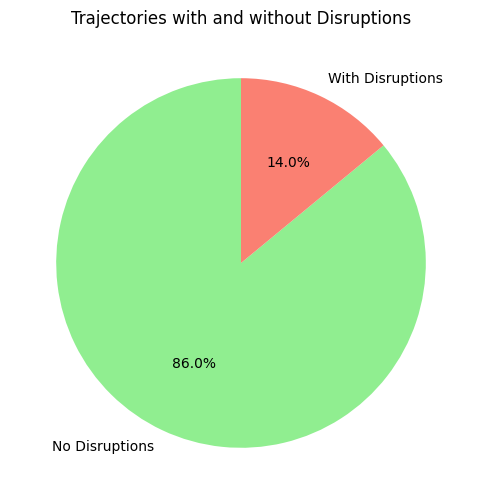

In [10]:
disrupted = (feature_df["Disrupted"] == True).sum()
non_disrupted =  (feature_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

In [11]:
# One-hot encode source and destination
source_encoded = pd.get_dummies(feature_df['source'], prefix='source')
destination_encoded = pd.get_dummies(feature_df['destination'], prefix='dest')

# Concatenate encoded columns with feature_df
feature_df_encoded = pd.concat([feature_df, source_encoded, destination_encoded], axis=1)

# Optionally drop original source and destination columns
feature_df_encoded = feature_df_encoded.drop(columns=['source', 'destination'])
feature_df_encoded

,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,preferential_attachment,adamic_adar_index,...,dest_Zaandam,dest_Zaltbommel,dest_Zandvoort aan Zee,dest_Zoetermeer,dest_Zoetermeer Oost,dest_Zuidbroek,dest_Zuidhorn,dest_Zutphen,dest_Zwijndrecht,dest_Zwolle
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,14,83,31.714286,13,52,39.230769,2,0.142857,182,0.936018,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,14,83,31.714286,36,243,21.305556,2,0.071429,504,0.780271,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,29,253,52.793103,21,116,40.142857,3,0.111111,609,1.305064,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,29,253,52.793103,36,243,21.305556,10,0.333333,1044,5.719831,...,False,False,False,False,False,False,False,False,False,False
2019-01-01,21,116,40.142857,29,253,52.793103,3,0.111111,609,1.305064,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,23,104,53.608696,15,78,59.133333,4,0.235294,345,1.888457,...,False,False,False,False,False,False,False,False,False,False
2024-12-31,23,104,53.608696,19,64,56.000000,7,0.411765,437,2.865774,...,False,False,False,False,False,False,False,False,False,False
2024-12-31,23,104,53.608696,18,83,53.277778,4,0.222222,414,1.773758,...,False,False,False,False,False,False,False,False,False,False


In [12]:
# Define feature columns
feature_columns = [col for col in feature_df_encoded.columns 
                   if col.startswith('source_') or col.startswith('dest_') or 
                   col in topo_features]

# Ensure numeric features
feature_df_encoded[feature_columns] = feature_df_encoded[feature_columns].apply(pd.to_numeric, errors='coerce')

# Define features (X) and target (y)
X_enc = feature_df_encoded[feature_columns]
y_enc = feature_df_encoded['Disrupted'].astype(int)  # Convert True/False to 1/0

In [13]:
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],      
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
}

# Define scoring metrics
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

xgb = XGBClassifier(objective='binary:logistic', eval_metric='auc', random_state=42)

In [14]:
param_grid_rf = {
        'n_estimators': [100, 200, 500, 1000],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }
rf = RandomForestClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}
gb = GradientBoostingClassifier(random_state=42)

In [15]:
param_grid_lg = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga', 'newton-cg'],
    }
logres = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

In [16]:
from xgboost import plot_importance
import shap

def plot_feature_importance(model, feature_names, max_num_features=20, model_type=None):
    """
    Plot feature importance for different model types.
    """
    if model_type == 'xgboost':
        plot_importance(model, max_num_features=max_num_features)
        plt.title("XGBoost Feature Importance")
        return
    elif model_type == 'logistic':
        importance = np.abs(model.coef_[0])
        importance_label = "Absolute Coefficient"
    elif model_type in ['random_forest', 'gradient_boosting']:
        importance = model.feature_importances_
        importance_label = "Feature Importance (Gini/Impurity Reduction)"
    else:
        raise ValueError("Unsupported model type. Use 'xgboost', 'logistic', 'random_forest', or 'gradient_boosting'.")

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(max_num_features)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"{model_type.replace('_', ' ').title()} Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_shap_values(model, X_test, feature_names, model_type=None):
    """
    Plot SHAP values for tree-based models.
    
    Parameters:
    - model: Trained tree-based model (RandomForestClassifier, GradientBoostingClassifier, XGBClassifier)
    - X_test: Test feature matrix (pandas DataFrame or numpy array)
    - feature_names: List of feature names
    - model_type: String indicating model type ('random_forest', 'gradient_boosting', 'xgboost')
    """

    if model_type not in ['random_forest', 'gradient_boosting', 'xgboost']:
        print(f"SHAP plotting is only supported for tree-based models, not '{model_type}'.")
        return
    
    # Convert X_test to DataFrame if it's a numpy array to ensure feature names are used
    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test, columns=feature_names)
    X_test = X_test.sample(n=1000, random_state=42)
    # Initialize SHAP TreeExplainer
    explainer = shap.TreeExplainer(model)
    
    # Compute SHAP values
    shap_values = explainer.shap_values(X_test)
    
    # For binary classification, shap_values may be a list (for XGBoost) or array
    # We typically want the SHAP values for the positive class (index 1 for binary classification)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Positive class for XGBoost
    
    # Plot SHAP summary plot
    plt.figure()
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, max_display=20, show=False)
    plt.title(f"SHAP Summary Plot for {model_type.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()


def optimise(model, scoring, param_grid, X, y):
    """
    Optimize a model using RandomizedSearchCV with time-series cross-validation,
    plot feature importance, and plot SHAP values for tree-based models.
    
    Parameters:
    - model: Model to optimize (e.g., XGBClassifier, LogisticRegression, etc.)
    - scoring: Scoring metric(s) for RandomizedSearchCV
    - param_grid: Parameter grid for RandomizedSearchCV
    - X: Feature matrix (pandas DataFrame or numpy array)
    - y: Target vector
    """
    test_size = 0.2
    n_samples = len(X)
    train_size = int((1 - test_size) * n_samples)
    
    X_train = X[:train_size]
    X_test = X[train_size:]
    y_train = y[:train_size]
    y_test = y[train_size:]
    
    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=6)
    
    # Randomized search with time-series CV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        refit='f1',
        cv=tscv,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    # Fit the model
    random_search.fit(X_train, y_train)
    
    # Results
    print("Best Parameters:", random_search.best_params_)
    print("Best F1 Score:", random_search.best_score_)
    
    # Evaluate best model
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.4f}")
    
    # Determine model type for feature importance and SHAP plotting
    if isinstance(best_model, XGBClassifier):
        model_type = 'xgboost'
    elif isinstance(best_model, LogisticRegression):
        model_type = 'logistic'
    elif isinstance(best_model, RandomForestClassifier):
        model_type = 'random_forest'
    elif isinstance(best_model, GradientBoostingClassifier):
        model_type = 'gradient_boosting'
    
    # Get feature names
    if isinstance(X, pd.DataFrame):
        feature_names = X.columns
    else:
        feature_names = [f"Feature_{i}" for i in range(X.shape[1])]
    
    # Plot feature importance
    plot_feature_importance(best_model, feature_names, max_num_features=20, model_type=model_type)
    
    # Plot SHAP values for tree-based models
    if model_type != 'Logistic':
        plot_shap_values(best_model, X_test, feature_names, model_type=model_type)
    
    return best_model

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Score: 0.4424348526334767
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.72      0.83    101733
        True       0.27      0.77      0.40     13298

    accuracy                           0.73    115031
   macro avg       0.61      0.75      0.61    115031
weighted avg       0.88      0.73      0.78    115031

Accuracy: 0.7293
F1 Score: 0.3956
Precision: 0.2667
Recall: 0.7664
Balanced Accuracy: 0.7454
AUC: 0.8235


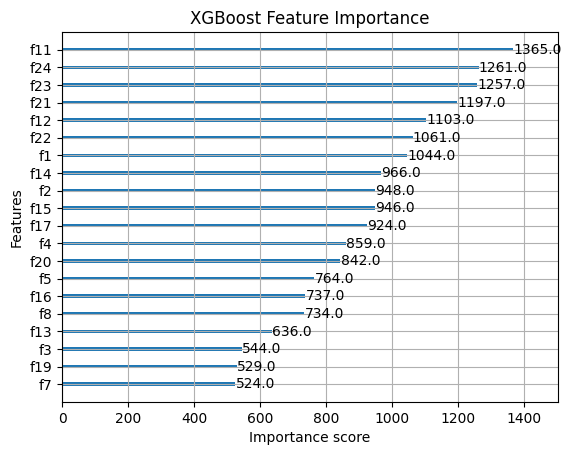

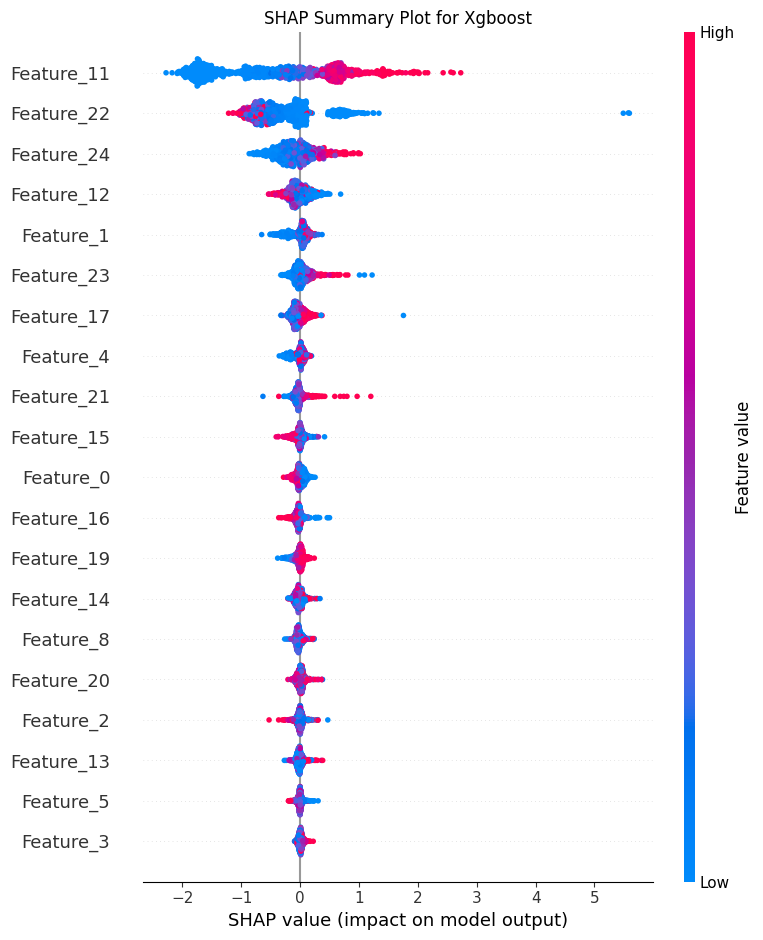

In [18]:
xgb_model = optimise(xgb, scoring, param_grid_xgb, X_comp, y)

Fitting 6 folds for each of 10 candidates, totalling 60 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
6 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
Best F1 Score: 0.29888813909396267
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94    101733
        True       0.52      0.20      0.29     13298

    accuracy                           0.89    115031
   macro avg       0.71      0.59      0.61    115031
weighted avg       0.86      0.89      0.86    115031

Accuracy: 0.8862
F1 Score: 0.2867
Precision: 0.5202
Recall: 0.1979
Balanced Accuracy: 0.5870
AUC: 0.8036


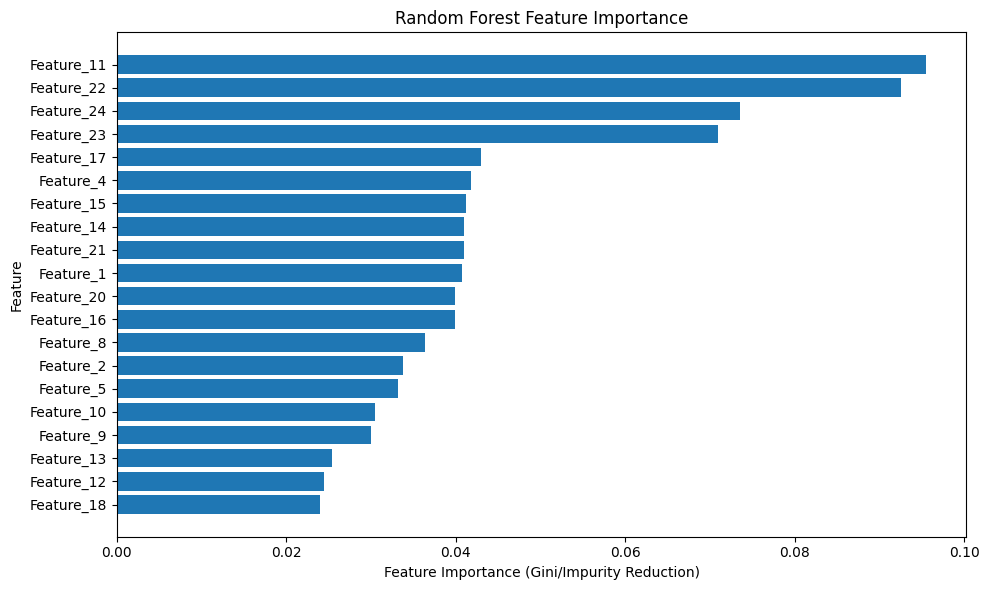

<Figure size 640x480 with 0 Axes>

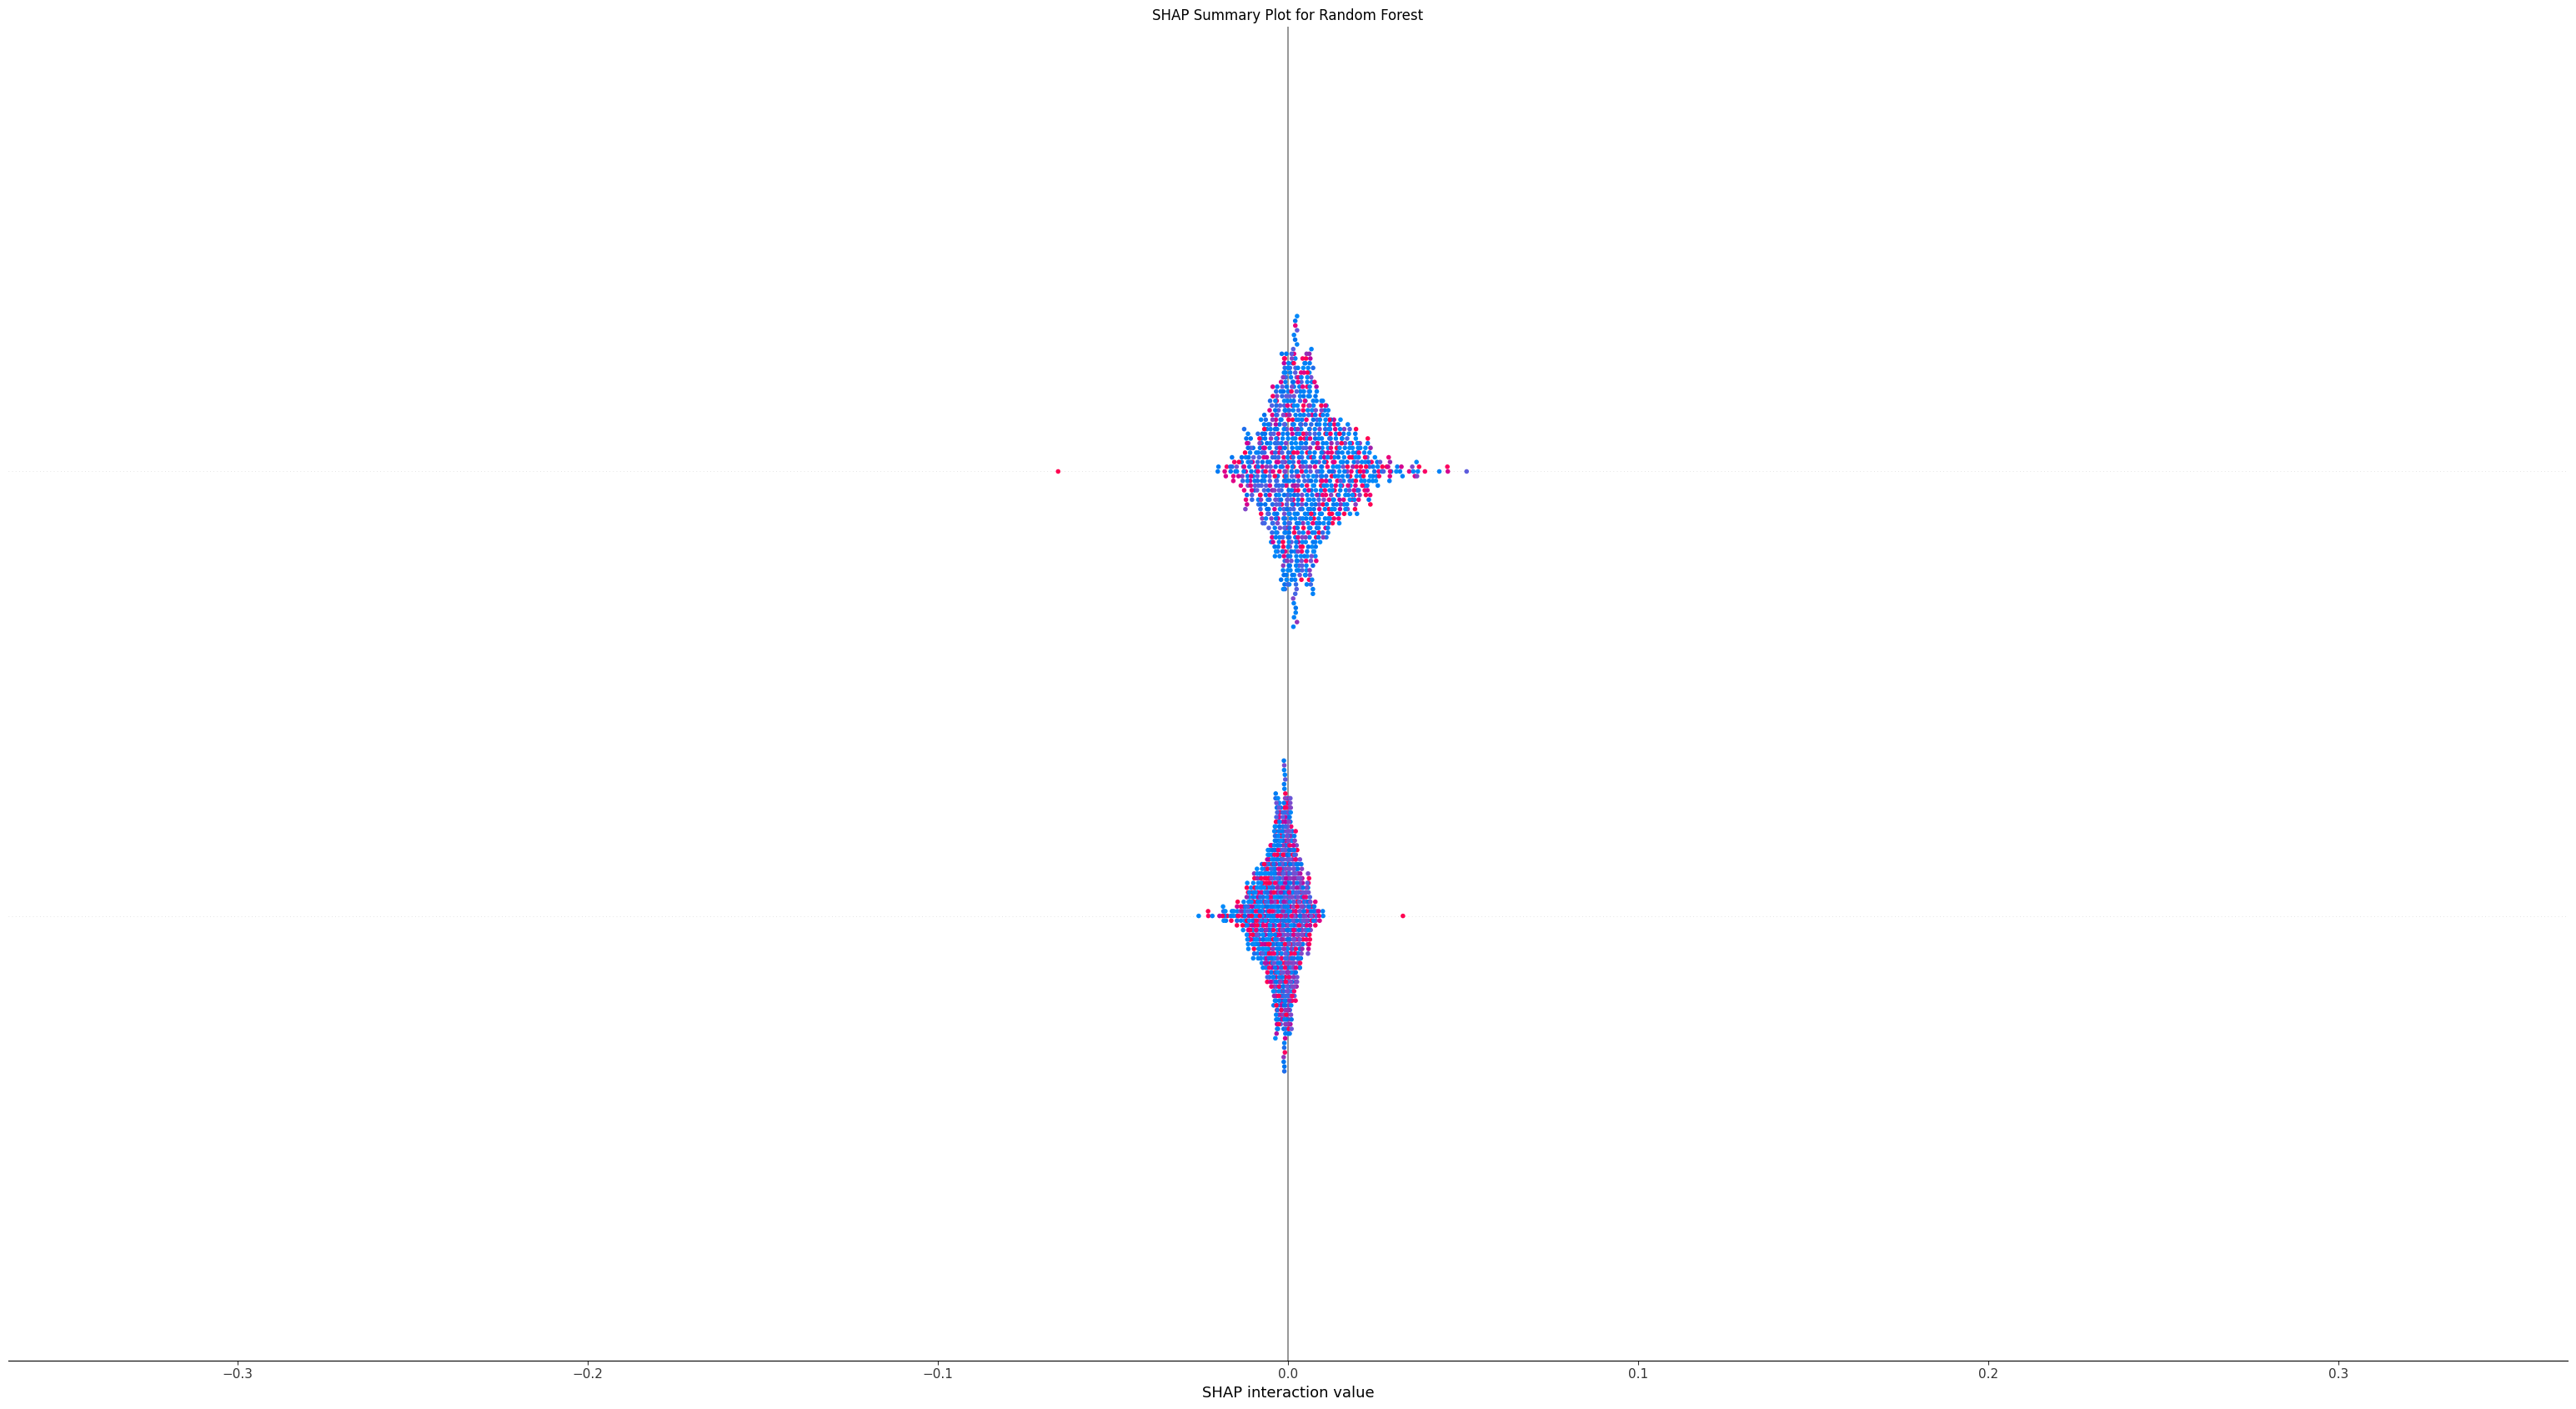

In [19]:
rf_model = optimise(rf, scoring, param_grid_rf, X_comp, y)

Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}
Best F1 Score: 0.34273253337763027
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.93    101733
        True       0.43      0.25      0.32     13298

    accuracy                           0.87    115031
   macro avg       0.67      0.61      0.63    115031
weighted avg       0.85      0.87      0.86    115031

Accuracy: 0.8746
F1 Score: 0.3197
Precision: 0.4289
Recall: 0.2548
Balanced Accuracy: 0.6052
AUC: 0.8097


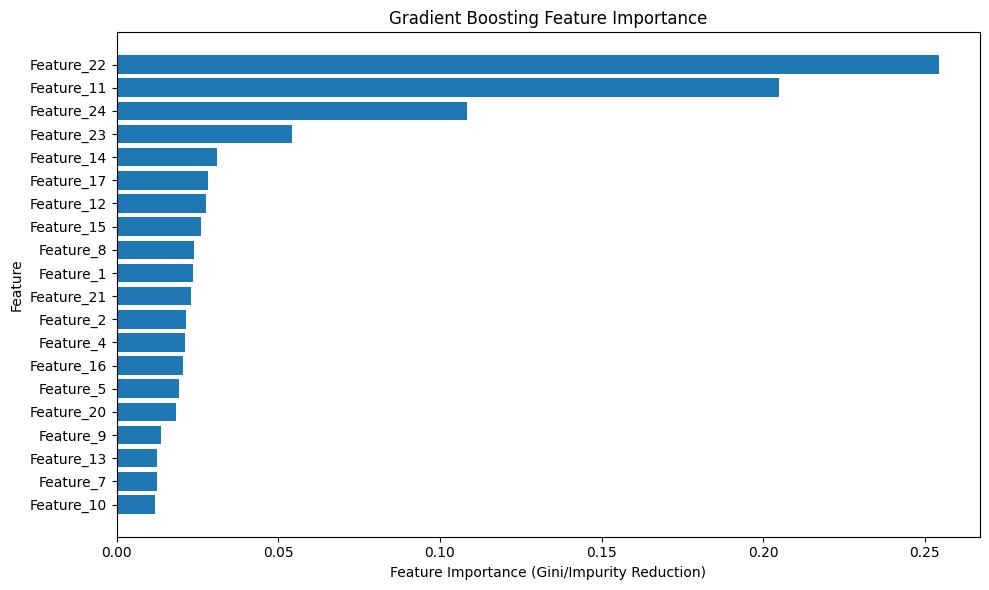

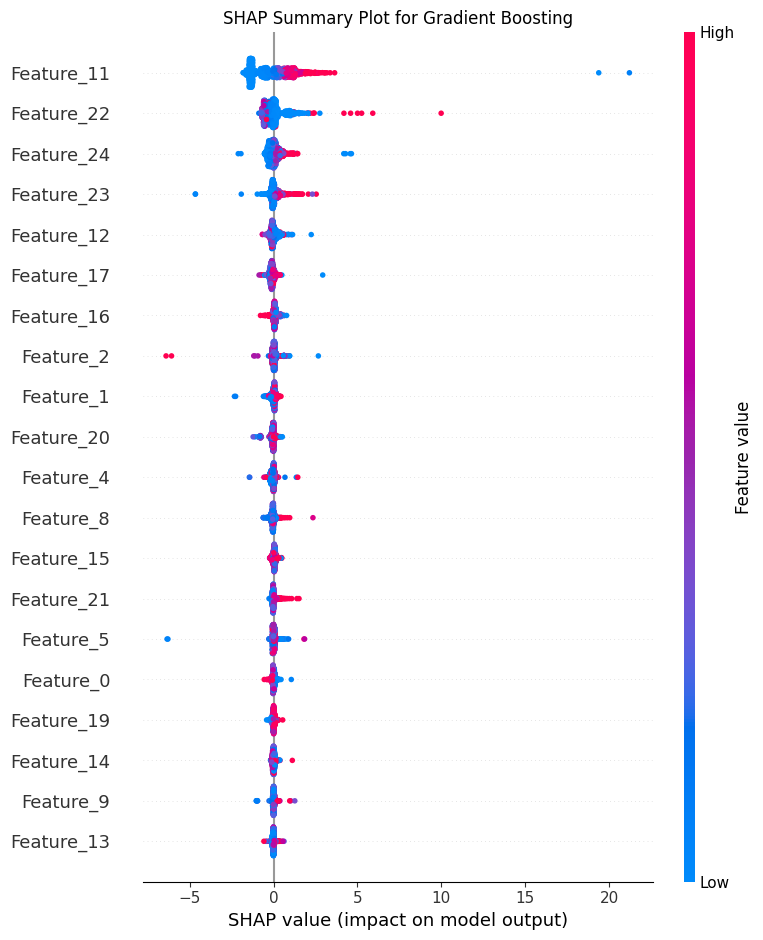

In [20]:
gb_model = optimise(gb, scoring, param_grid_gb, X_comp, y)

Fitting 6 folds for each of 10 candidates, totalling 60 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
18 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Best F1 Score: 0.39869097716492913
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.95      0.70      0.81    101733
        True       0.25      0.75      0.37     13298

    accuracy                           0.71    115031
   macro avg       0.60      0.72      0.59    115031
weighted avg       0.87      0.71      0.76    115031

Accuracy: 0.7072
F1 Score: 0.3704
Precision: 0.2465
Recall: 0.7452
Balanced Accuracy: 0.7237
AUC: 0.7950


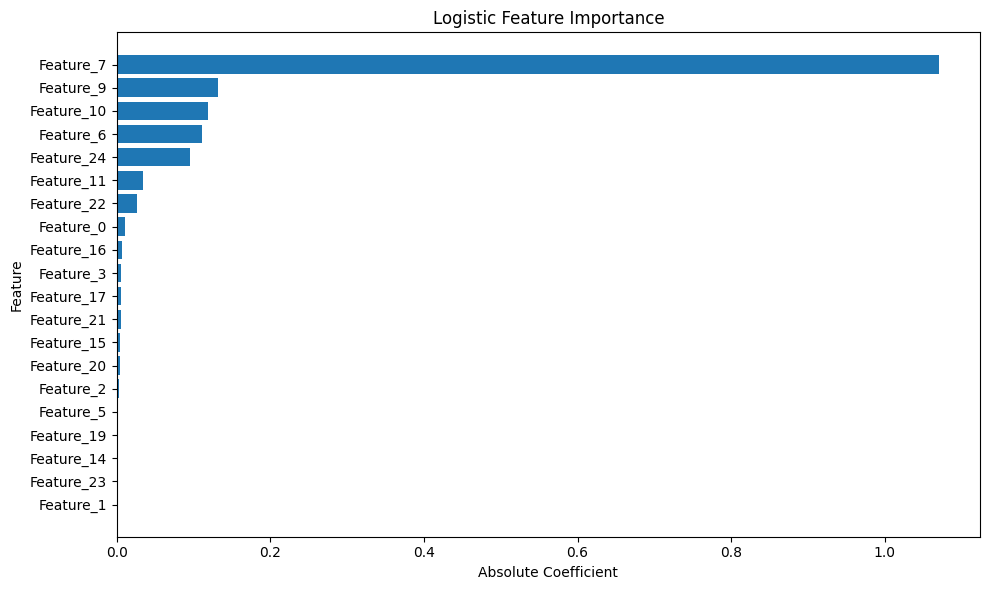

SHAP plotting is only supported for tree-based models, not 'logistic'.


In [27]:
logres_model = optimise(logres, scoring, param_grid_lg, X_comp, y)

In [21]:
best_parameters_lr = {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
best_parameters_xgb = {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 1.0}
best_parameters_rf = {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
best_parameters_gb = {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}

In [17]:
def compare_models(X, y, resample=True, n_splits=6):
    scaler = StandardScaler()
    tss = TimeSeriesSplit(n_splits=n_splits)
    
    # Initialize classifiers
    logres = LogisticRegression(random_state=42, class_weight='balanced')
    rf = RandomForestClassifier(random_state=42, class_weight='balanced', **best_parameters_rf)
    xgb = XGBClassifier(random_state=42, **best_parameters_xgb)
    gbdt = GradientBoostingClassifier(random_state=42, **best_parameters_gb)
    classifiers = [logres, rf, xgb, gbdt]
    
    # Store metrics for each model and fold
    model_metrics = {
        clf.__class__.__name__: {'balanced_acc': [], 'f1': [], 'auc': []} 
        for clf in classifiers
    }
    
    # Split the data into train and test sets
    for fold, (train_index, test_index) in enumerate(tss.split(X), 1):
        print(f"\nFold {fold}/{n_splits}")
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Apply SMOTE to training set if resample=True
        if resample:
            smote = SMOTE(random_state=42)
            X_train, y_train = smote.fit_resample(X_train, y_train)
        
        # Scale the features
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Update scale_pos_weight for XGBClassifier based on training data
        if sum(y_train == 1) > 0:  # Avoid division by zero
            xgb.set_params(scale_pos_weight=sum(y_train == 0) / sum(y_train == 1))
        
        # Train and evaluate each classifier
        for classifier in classifiers:
            # Fit the classifier
            classifier.fit(X_train_scaled, y_train)
            
            # Predict on the test set
            y_test_pred = classifier.predict(X_test_scaled)
            y_test_proba = classifier.predict_proba(X_test_scaled)[:, 1] if hasattr(classifier, 'predict_proba') else y_test_pred
            
            # Calculate metrics for this fold
            balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
            f1 = f1_score(y_test, y_test_pred)
            auc = roc_auc_score(y_test, y_test_proba)
            
            # Store metrics
            model_metrics[classifier.__class__.__name__]['balanced_acc'].append(balanced_acc)
            model_metrics[classifier.__class__.__name__]['f1'].append(f1)
            model_metrics[classifier.__class__.__name__]['auc'].append(auc)
    
    # Calculate mean and std of metrics for each model
    rows = []
    for model_name in model_metrics:
        balanced_acc_mean = np.mean(model_metrics[model_name]['balanced_acc'])
        balanced_acc_std = np.std(model_metrics[model_name]['balanced_acc'])
        f1_mean = np.mean(model_metrics[model_name]['f1'])
        f1_std = np.std(model_metrics[model_name]['f1'])
        auc_mean = np.mean(model_metrics[model_name]['auc'])
        auc_std = np.std(model_metrics[model_name]['auc'])
        
        print(f"\nAggregated metrics for {model_name}:")
        print(f"Balanced Accuracy: {balanced_acc_mean:.4f} ± {balanced_acc_std:.4f}")
        print(f"F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f"AUC: {auc_mean:.4f} ± {auc_std:.4f}")
        
        # Store metrics
        row = {
            'model': model_name,
            'balanced_acc_mean': balanced_acc_mean,
            'balanced_acc_std': balanced_acc_std,
            'f1_mean': f1_mean,
            'f1_std': f1_std,
            'auc_mean': auc_mean,
            'auc_std': auc_std
        }
        rows.append(row)
    
    return rows

In [40]:
compare_models(X_comp, y, False)


Fold 1/6

Fold 2/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 3/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 4/6


...

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 6/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.9649 ± 0.0140
F1 Score: 0.8686 ± 0.0572
AUC: 0.9874 ± 0.0079

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.5482 ± 0.0170
F1 Score: 0.1776 ± 0.0567
AUC: 0.7973 ± 0.0271

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.8056 ± 0.0156
F1 Score: 0.5378 ± 0.0586
AUC: 0.8984 ± 0.0141

Aggregated metrics for GradientBoostingClassifier:
Balanced Accuracy: 0.8365 ± 0.0452
F1 Score: 0.7247 ± 0.0736
AUC: 0.9576 ± 0.0118


[{'model': 'LogisticRegression',
  'balanced_acc_mean': 0.9648946947251797,
  'balanced_acc_std': 0.013963848988983231,
  'f1_mean': 0.8686047554740034,
  'f1_std': 0.057189621433476105,
  'auc_mean': 0.9874241111577601,
  'auc_std': 0.007949357851707552},
 {'model': 'RandomForestClassifier',
  'balanced_acc_mean': 0.5482229492995899,
  'balanced_acc_std': 0.017016414958122183,
  'f1_mean': 0.1776051531488364,
  'f1_std': 0.05667289661080579,
  'auc_mean': 0.7972743328332329,
  'auc_std': 0.027130449308109792},
 {'model': 'XGBClassifier',
  'balanced_acc_mean': 0.8056215539475954,
  'balanced_acc_std': 0.015586690228557654,
  'f1_mean': 0.5378498156328613,
  'f1_std': 0.05857437634319962,
  'auc_mean': 0.8983729466251967,
  'auc_std': 0.01407931985222448},
 {'model': 'GradientBoostingClassifier',
  'balanced_acc_mean': 0.8364996720604884,
  'balanced_acc_std': 0.04522254675178669,
  'f1_mean': 0.7247226550606868,
  'f1_std': 0.07356149198307796,
  'auc_mean': 0.9576039434887166,
  'auc

In [26]:
rows_1 = compare_models(X_topo, y, False)
rows_2 = compare_models(X_topo, y, True)
rows_3 = compare_models(X_wthr, y, False)
rows_4 = compare_models(X_oper, y, False)
rows_5 = compare_models(X_tnw, y, False)
rows_6 = compare_models(X_wno, y, False)
rows_7 = compare_models(X_tno, y, False)
rows_8 = compare_models(X_comp, y, False)

results_df = pd.DataFrame(rows_1)
results_df['model'] = results_df['model'].apply(lambda x: x + ' Topology features')
for row in rows_2:
    row['model'] = row['model'] + ' Topology features (SMOTE)'
results_df = pd.concat([results_df, pd.DataFrame(rows_2)], ignore_index=True)
for row in rows_3:
    row['model'] = row['model'] + ' Weather features'
results_df = pd.concat([results_df, pd.DataFrame(rows_3)], ignore_index=True)
for row in rows_4:
    row['model'] = row['model'] + ' Operational features'
results_df = pd.concat([results_df, pd.DataFrame(rows_4)], ignore_index=True)
for row in rows_5:
    row['model'] = row['model'] + ' Topology and Weather features'
results_df = pd.concat([results_df, pd.DataFrame(rows_5)], ignore_index=True)
for row in rows_6:
    row['model'] = row['model'] + ' Weather and Operational features'
results_df = pd.concat([results_df, pd.DataFrame(rows_6)], ignore_index=True)
for row in rows_7:
    row['model'] = row['model'] + ' Topology and Operational features'
results_df = pd.concat([results_df, pd.DataFrame(rows_7)], ignore_index=True)
for row in rows_8:
    row['model'] = row['model'] + ' All features'
results_df = pd.concat([results_df, pd.DataFrame(rows_8)], ignore_index=True)

# Generate LaTeX table manually (replace with actual values)
latex_table = """
\\begin{table}[ht]
\\centering
\\caption{Cross-Validation Performance Metrics (Mean $\\pm$ Standard Deviation)}
\\begin{tabular}{lccc}
\\hline
\\textbf{Model} & \\textbf{Balanced Accuracy} & \\textbf{F1 Score} & \\textbf{AUC} \\\\
\\hline
"""
for _, row in results_df.iterrows():
    latex_table += f"{row['model']} & {row['balanced_acc_mean']:.3f} $\\pm$ {row['balanced_acc_std']:.3f} & {row['f1_mean']:.3f} $\\pm$ {row['f1_std']:.3f} & {row['auc_mean']:.3f} $\\pm$ {row['auc_std']:.3f} \\\\\n"
latex_table += """
\\hline
\\end{tabular}
\\end{table}
"""
print(latex_table)


Fold 1/6

Fold 2/6

Fold 3/6

Fold 4/6

Fold 5/6

Fold 6/6

Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.6763 ± 0.0275
F1 Score: 0.3823 ± 0.0368
AUC: 0.7392 ± 0.0384

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.5851 ± 0.0211
F1 Score: 0.2857 ± 0.0371
AUC: 0.7524 ± 0.0347

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.7025 ± 0.0347
F1 Score: 0.4028 ± 0.0290
AUC: 0.7724 ± 0.0429

Aggregated metrics for GradientBoostingClassifier:
Balanced Accuracy: 0.5765 ± 0.0171
F1 Score: 0.2662 ± 0.0425
AUC: 0.7809 ± 0.0406

Fold 1/6

Fold 2/6

Fold 3/6

Fold 4/6

Fold 5/6

Fold 6/6

Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.6759 ± 0.0281
F1 Score: 0.3815 ± 0.0367
AUC: 0.7394 ± 0.0388

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.6314 ± 0.0262
F1 Score: 0.3640 ± 0.0335
AUC: 0.7598 ± 0.0291

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.6470 ± 0.0288
F1 Score: 0.3827 ± 0.0346
AUC: 0.7616 ±

In [27]:
results_df

,model,balanced_acc_mean,balanced_acc_std,f1_mean,f1_std,auc_mean,auc_std
0,LogisticRegression Topology features,0.676297,0.027527,0.382273,0.036831,0.739245,0.038359
1,RandomForestClassifier Topology features,0.585073,0.021087,0.285672,0.037121,0.752357,0.034657
2,XGBClassifier Topology features,0.702516,0.034667,0.402827,0.029012,0.772379,0.042875
3,GradientBoostingClassifier Topology features,0.576537,0.017104,0.266228,0.042451,0.780854,0.040597
4,LogisticRegression Topology features (SMOTE),0.675864,0.028067,0.381516,0.036677,0.739407,0.038807
5,RandomForestClassifier Topology features (SMOTE),0.631450,0.026177,0.363955,0.033508,0.759829,0.029103
6,XGBClassifier Topology features (SMOTE),0.647024,0.028805,0.382723,0.034632,0.761601,0.042224
7,GradientBoostingClassifier Topology features (...,0.635234,0.025198,0.373679,0.037198,0.770516,0.041037
8,LogisticRegression Weather features,0.510858,0.006982,0.222357,0.032734,0.512400,0.013800
9,RandomForestClassifier Weather features,0.501237,0.003698,0.059059,0.016940,0.499100,0.006595


In [26]:
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
X_comp_reshaped = X_comp.reshape((X_comp.shape[0], 1, X_comp.shape[1]))

def cross_validate_lstm(X, y, features, resample=False, n_splits=6, epochs=50, batch_size=32):
    scaler = StandardScaler()
    tss = TimeSeriesSplit(n_splits=n_splits)
    
    # Store metrics for each fold and model
    metrics = {
        'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': [], 'balanced_acc': []
    }
    fold_results = []
    
    # Cross-validation loop
    for fold, (train_index, test_index) in enumerate(tss.split(X), 1):
        print(f"\nFold {fold}/{n_splits}")
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Apply SMOTE to training set if resample=True
        if resample:
            smote = SMOTE(random_state=42)
            # X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
            X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
            X_train = X_train_balanced.reshape(-1, X_train.shape[1], X_train.shape[2])
            y_train = y_train_balanced
        
        # Scale the features
        X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
        X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)
        
        # Convert labels to categorical
        y_train_categorical = to_categorical(y_train)
        y_test_categorical = to_categorical(y_test)
        
        # Build the LSTM model
        model = Sequential([
            LSTM(128, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]), 
                 activation='relu', return_sequences=True),
            LSTM(64, activation='relu', return_sequences=False),
            Dense(32, activation='relu'),
            Dense(y_train_categorical.shape[1], activation='softmax')
        ])
        
        # Compile the model
        model.compile(optimizer='adam', 
                      loss='categorical_crossentropy', 
                      metrics=['accuracy', 'Precision', 'Recall', 'AUC'])
        
        # Train the model with early stopping
        early_stopping = EarlyStopping(monitor='val_Recall', patience=5, mode='max', restore_best_weights=True)
        history = model.fit(
            X_train_scaled, y_train_categorical,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,  # Uses last 20% of training data (time-ordered)
            callbacks=[early_stopping],
            verbose=1
        )
        
        # Evaluate the model on the test set
        loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical, verbose=0)
        y_pred_proba = model.predict(X_test_scaled)
        y_pred_classes = np.argmax(y_pred_proba, axis=1)
        y_test_classes = np.argmax(y_test_categorical, axis=1)
        
        # Calculate additional metrics
        f1 = f1_score(y_test_classes, y_pred_classes)
        balanced_acc = balanced_accuracy_score(y_test_classes, y_pred_classes)
        auc_roc = roc_auc_score(y_test_classes, y_pred_proba[:, 1])  # Use probabilities for AUC
        
        # Store metrics for this fold
        metrics['accuracy'].append(accuracy)
        metrics['precision'].append(precision)
        metrics['recall'].append(recall)
        metrics['f1'].append(f1)
        metrics['auc'].append(auc_roc)
        metrics['balanced_acc'].append(balanced_acc)
        
        # Print fold results
        print(f"Test Loss: {loss:.4f}")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Precision: {precision:.4f}")
        print(f"Test Recall: {recall:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
        print(f"Test AUC: {auc_roc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test_classes, y_pred_classes))
        cm = confusion_matrix(y_test_classes, y_pred_classes)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['No Disruption', 'Disruption'], 
                    yticklabels=['No Disruption', 'Disruption'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix (Fold {fold})')
        plt.show()
        
        # Store fold results for later analysis
        fold_results.append({
            'fold': fold,
            'y_true': y_test_classes,
            'y_pred': y_pred_classes,
            'y_proba': y_pred_proba[:, 1]
        })
    
    # Aggregate and print cross-validation results
    print("\nCross-Validation Results (Mean ± Std):")
    results = {
        'accuracy': np.mean(metrics['accuracy']),
        'precision': np.mean(metrics['precision']),
        'recall': np.mean(metrics['recall']),
        'f1': np.mean(metrics['f1']),
        'auc': np.mean(metrics['auc']),
        'balanced_acc': np.mean(metrics['balanced_acc'])
    }
    for metric in metrics:
        mean = np.mean(metrics[metric])
        std = np.std(metrics[metric])
        print(f"{metric.capitalize()}: {mean:.4f} ± {std:.4f}")
    return model, metrics, results

In [ ]:
features = feature_df.drop(columns=['source', 'destination', 'Disrupted', 'Previous_causes_vec', 'Most_recent_causes_vec', 'Total_disruptions', 'Total_rides']).columns.tolist()
final_model, cv_metrics, feature_importance = cross_validate_lstm(
    X=X_comp_reshaped, 
    y=y, 
    features=features, 
    resample=True, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)

In [20]:
def lstm_predict(X, y, model, n_splits):
    tss = TimeSeriesSplit(n_splits=n_splits)
    scaler = StandardScaler()
    
    # Store metrics for each fold and model
    metrics = {
        'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': [], 'balanced_acc': []
    }
    fold_results = []

    for fold, (train_index, test_index) in enumerate(tss.split(X), 1):
        print(f"\nFold {fold}/{n_splits}")
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Apply SMOTE to training set if resample=True
        
        # Scale the features
        X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
        X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)
        
        # Convert labels to categorical
        y_train_categorical = to_categorical(y_train)
        y_test_categorical = to_categorical(y_test)
        
        y_pred_proba = model.predict(X_test_scaled)
        y_pred_classes = np.argmax(y_pred_proba, axis=1)
        y_test_classes = np.argmax(y_test_categorical, axis=1)
        
        # Calculate additional metrics
        loss, accuracy, precision, recall, auc = model.evaluate(X_test_scaled, y_test_categorical, verbose=0)
        f1 = f1_score(y_test_classes, y_pred_classes)
        balanced_acc = balanced_accuracy_score(y_test_classes, y_pred_classes)
        auc_roc = roc_auc_score(y_test_classes, y_pred_proba[:, 1])  # Use probabilities for AUC
        y_pred_proba = model.predict(X_test_scaled)

        # Store metrics for this fold
        metrics['accuracy'].append(accuracy)
        metrics['precision'].append(precision)
        metrics['recall'].append(recall)
        metrics['f1'].append(f1)
        metrics['auc'].append(auc_roc)
        metrics['balanced_acc'].append(balanced_acc)
        # Print fold results
        print(f"Test Loss: {loss:.4f}")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Precision: {precision:.4f}")
        print(f"Test Recall: {recall:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
        print(f"Test AUC: {auc_roc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test_classes, y_pred_classes))
        cm = confusion_matrix(y_test_classes, y_pred_classes)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['No Disruption', 'Disruption'], 
                    yticklabels=['No Disruption', 'Disruption'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Confusion Matrix (Fold {fold})')
        plt.show()
        # Store fold results for later analysis
        fold_results.append({
            'fold': fold,
            'y_true': y_test_classes,
            'y_pred': y_pred_classes,
            'y_proba': y_pred_proba[:, 1]
        })
        
        # Aggregate and print cross-validation results
    print("\nCross-Validation Results (Mean ± Std):")
    results = {
        'accuracy': np.mean(metrics['accuracy']),
        'precision': np.mean(metrics['precision']),
        'recall': np.mean(metrics['recall']),
        'f1': np.mean(metrics['f1']),
        'auc': np.mean(metrics['auc']),
        'balanced_acc': np.mean(metrics['balanced_acc'])
    }
    for metric in metrics:
        mean = np.mean(metrics[metric])
        std = np.std(metrics[metric])
        print(f"{metric.capitalize()}: {mean:.4f} ± {std:.4f}")
    return metrics, results


lstm_predict(X_comp_reshaped, y, final_model, n_splits=6)
    


NameError: name 'final_model' is not defined


Fold 1/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - AUC: 0.8897 - Precision: 0.8715 - Recall: 0.8715 - accuracy: 0.8715 - loss: 0.3868 - val_AUC: 0.9029 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3614
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - AUC: 0.9031 - Precision: 0.8685 - Recall: 0.8685 - accuracy: 0.8685 - loss: 0.3696 - val_AUC: 0.9299 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3321
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - AUC: 0.9228 - Precision: 0.8720 - Recall: 0.8720 - accuracy: 0.8720 - loss: 0.3445 - val_AUC: 0.9293 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3332
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - AUC: 0.9256 - Precision: 0.8727 - Recall: 0.8727 - accuracy: 0.8727 - loss: 0.3399 - val_AUC: 0.9313 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3311
Epoch 5/50
2055/

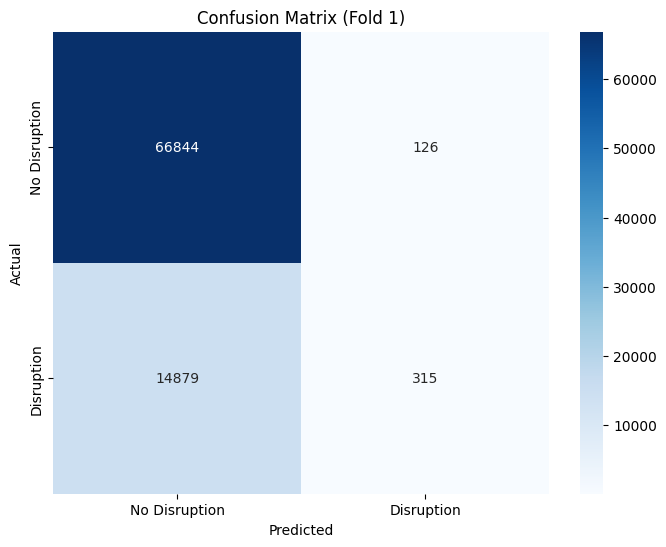


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - AUC: 0.8614 - Precision: 0.8383 - Recall: 0.8383 - accuracy: 0.8383 - loss: 0.4391 - val_AUC: 0.9098 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3741
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - AUC: 0.8837 - Precision: 0.8387 - Recall: 0.8387 - accuracy: 0.8387 - loss: 0.4169 - val_AUC: 0.9261 - val_Precision: 0.8641 - val_Recall: 0.8641 - val_accuracy: 0.8641 - val_loss: 0.3487
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - AUC: 0.8893 - Precision: 0.8392 - Recall: 0.8392 - accuracy: 0.8392 - loss: 0.4105 - val_AUC: 0.9260 - val_Precision: 0.8645 - val_Recall: 0.8645 - val_accuracy: 0.8645 - val_loss: 0.3488
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - AUC: 0.8907 - Precision: 0.8402 - Recall: 0.8402 - accuracy: 0.8402 - loss: 0.4084 - val_AUC: 0.9257 - val_Precision: 0.8641 - val_Recall: 0.8641 - val_accuracy: 0.8641 - val_loss: 0.3539
Epoch 5/50
4109/4109 ━━━━━━

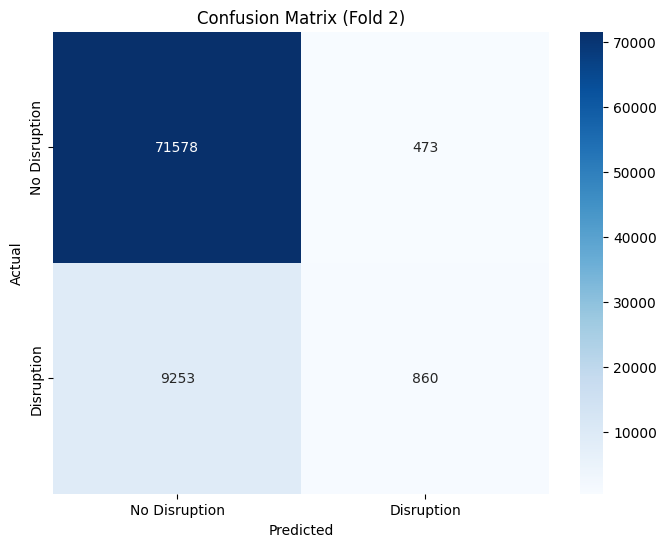


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - AUC: 0.8723 - Precision: 0.8452 - Recall: 0.8452 - accuracy: 0.8452 - loss: 0.4231 - val_AUC: 0.9435 - val_Precision: 0.8908 - val_Recall: 0.8908 - val_accuracy: 0.8908 - val_loss: 0.3092
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - AUC: 0.8973 - Precision: 0.8467 - Recall: 0.8467 - accuracy: 0.8467 - loss: 0.3954 - val_AUC: 0.9434 - val_Precision: 0.8906 - val_Recall: 0.8906 - val_accuracy: 0.8906 - val_loss: 0.3040
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - AUC: 0.8984 - Precision: 0.8464 - Recall: 0.8464 - accuracy: 0.8464 - loss: 0.3944 - val_AUC: 0.9460 - val_Precision: 0.8941 - val_Recall: 0.8941 - val_accuracy: 0.8941 - val_loss: 0.2970
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 60s 10ms/step - AUC: 0.9030 - Precision: 0.8493 - Recall: 0.8493 - accuracy: 0.8493 - loss: 0.3869 - val_AUC: 0.9448 - val_Precision: 0.8944 - val_Recall: 0.8944 - val_accuracy: 0.8944 - val_loss: 0.2988
Epoch 5/50
6163/6163 ━━━━━━━

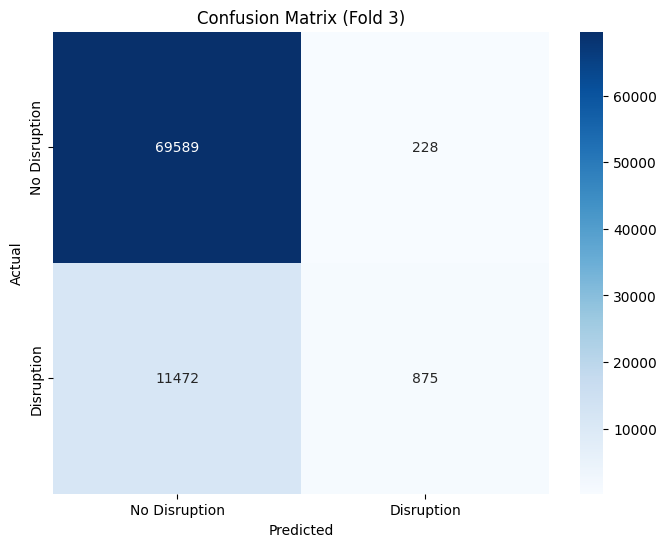


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 92s 11ms/step - AUC: 0.8862 - Precision: 0.8550 - Recall: 0.8550 - accuracy: 0.8550 - loss: 0.4016 - val_AUC: 0.9185 - val_Precision: 0.8533 - val_Recall: 0.8533 - val_accuracy: 0.8533 - val_loss: 0.3636
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - AUC: 0.9093 - Precision: 0.8584 - Recall: 0.8584 - accuracy: 0.8584 - loss: 0.3731 - val_AUC: 0.9186 - val_Precision: 0.8524 - val_Recall: 0.8524 - val_accuracy: 0.8524 - val_loss: 0.3671
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - AUC: 0.9103 - Precision: 0.8578 - Recall: 0.8578 - accuracy: 0.8578 - loss: 0.3720 - val_AUC: 0.9203 - val_Precision: 0.8529 - val_Recall: 0.8529 - val_accuracy: 0.8529 - val_loss: 0.3633
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - AUC: 0.9123 - Precision: 0.8582 - Recall: 0.8582 - accuracy: 0.8582 - loss: 0.3687 - val_AUC: 0.9189 - val_Precision: 0.8516 - val_Recall: 0.8516 - val_accuracy: 0.8516 - val_loss: 0.3631
Epoch 5/50
8217/8217 ━━━━━━

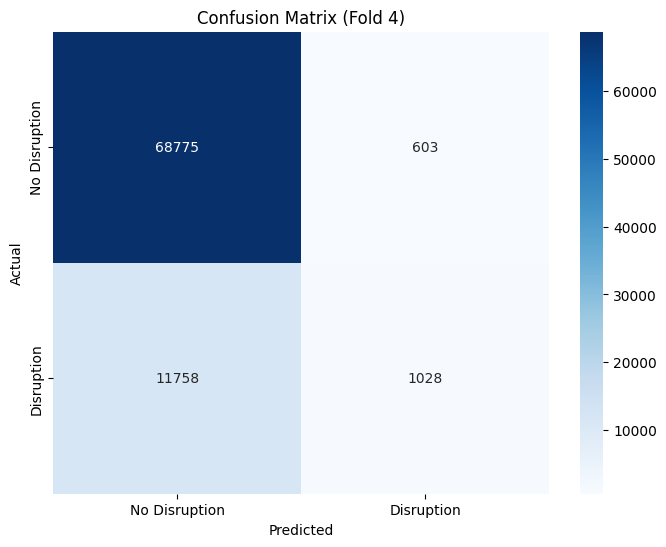


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 113s 11ms/step - AUC: 0.8897 - Precision: 0.8548 - Recall: 0.8548 - accuracy: 0.8548 - loss: 0.3986 - val_AUC: 0.9153 - val_Precision: 0.8485 - val_Recall: 0.8485 - val_accuracy: 0.8485 - val_loss: 0.3710
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 106s 10ms/step - AUC: 0.9098 - Precision: 0.8567 - Recall: 0.8567 - accuracy: 0.8567 - loss: 0.3737 - val_AUC: 0.9145 - val_Precision: 0.8479 - val_Recall: 0.8479 - val_accuracy: 0.8479 - val_loss: 0.3721
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 109s 11ms/step - AUC: 0.9120 - Precision: 0.8563 - Recall: 0.8563 - accuracy: 0.8563 - loss: 0.3704 - val_AUC: 0.9158 - val_Precision: 0.8490 - val_Recall: 0.8490 - val_accuracy: 0.8490 - val_loss: 0.3684
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 108s 11ms/step - AUC: 0.9147 - Precision: 0.8581 - Recall: 0.8581 - accuracy: 0.8581 - loss: 0.3656 - val_AUC: 0.9158 - val_Precision: 0.8489 - val_Recall: 0.8489 - val_accuracy: 0.8489 - val_loss: 0.3727
Epoch 5/50
1027

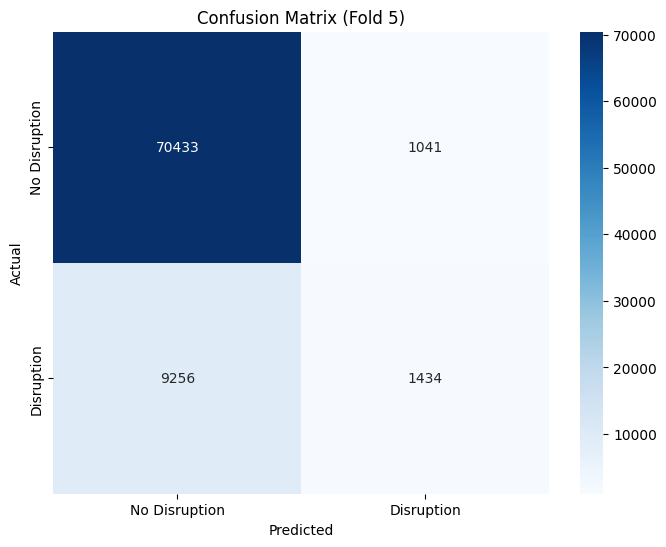


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 133s 11ms/step - AUC: 0.8874 - Precision: 0.8507 - Recall: 0.8507 - accuracy: 0.8507 - loss: 0.4035 - val_AUC: 0.9332 - val_Precision: 0.8746 - val_Recall: 0.8746 - val_accuracy: 0.8746 - val_loss: 0.3275
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 1160s 94ms/step - AUC: 0.9113 - Precision: 0.8537 - Recall: 0.8537 - accuracy: 0.8537 - loss: 0.3731 - val_AUC: 0.9351 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3226
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 125s 10ms/step - AUC: 0.9139 - Precision: 0.8550 - Recall: 0.8550 - accuracy: 0.8550 - loss: 0.3685 - val_AUC: 0.9347 - val_Precision: 0.8777 - val_Recall: 0.8777 - val_accuracy: 0.8777 - val_loss: 0.3268
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 127s 10ms/step - AUC: 0.9148 - Precision: 0.8551 - Recall: 0.8551 - accuracy: 0.8551 - loss: 0.3671 - val_AUC: 0.9362 - val_Precision: 0.8764 - val_Recall: 0.8764 - val_accuracy: 0.8764 - val_loss: 0.3206
Epoch 5/50
123

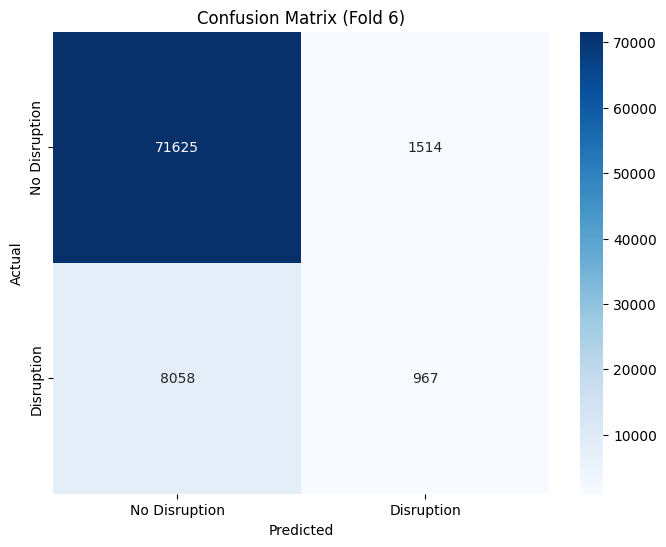


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8607 ± 0.0230
Precision: 0.8607 ± 0.0230
Recall: 0.8607 ± 0.0230
F1: 0.1415 ± 0.0532
Auc: 0.7491 ± 0.0354
Balanced_acc: 0.5369 ± 0.0149

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step
Test Loss: 0.4137
Test Accuracy: 0.8261
Test Precision: 0.8261
Test Recall: 0.8261
Test F1 Score: 0.1881
Test Balanced Accuracy: 0.5489
Test AUC: 0.7525

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     66970
           1       0.69      0.11      0.19     15194

    accuracy                           0.83     82164
   macro avg       0.76      0.55      0.55     82164
weighted avg       0.80      0.83      0.77     82164



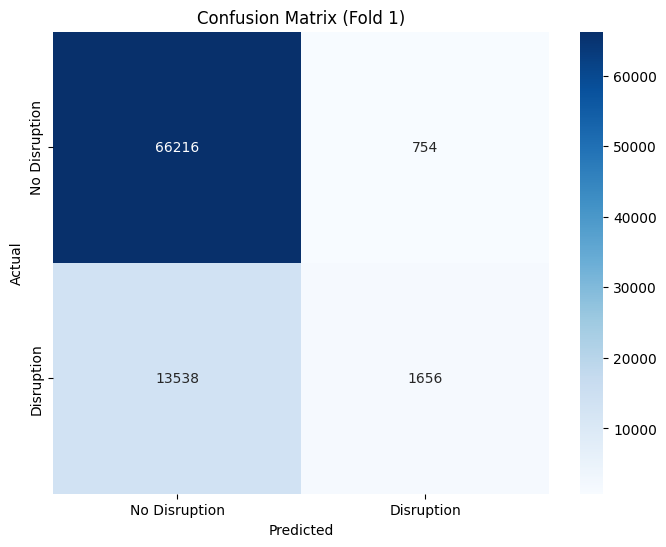


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Test Loss: 0.3125
Test Accuracy: 0.8839
Test Precision: 0.8839
Test Recall: 0.8839
Test F1 Score: 0.1877
Test Balanced Accuracy: 0.5508
Test AUC: 0.7958

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     72051
           1       0.68      0.11      0.19     10113

    accuracy                           0.88     82164
   macro avg       0.78      0.55      0.56     82164
weighted avg       0.86      0.88      0.85     82164



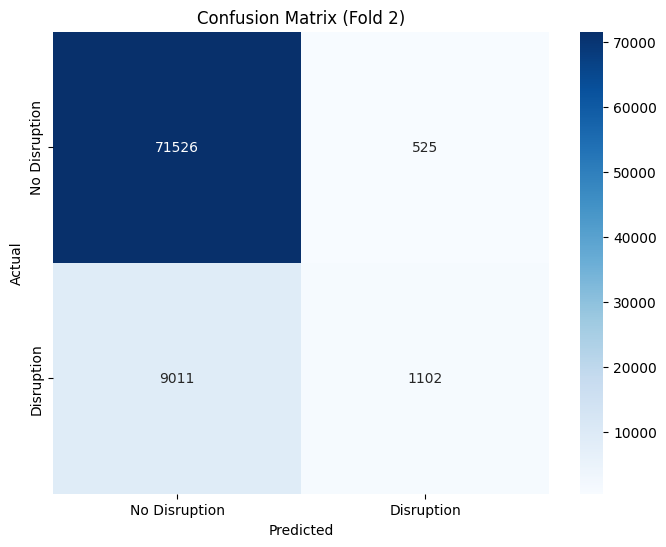


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Test Loss: 0.3437
Test Accuracy: 0.8596
Test Precision: 0.8596
Test Recall: 0.8596
Test F1 Score: 0.2057
Test Balanced Accuracy: 0.5556
Test AUC: 0.8029

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     69817
           1       0.69      0.12      0.21     12347

    accuracy                           0.86     82164
   macro avg       0.78      0.56      0.56     82164
weighted avg       0.84      0.86      0.82     82164



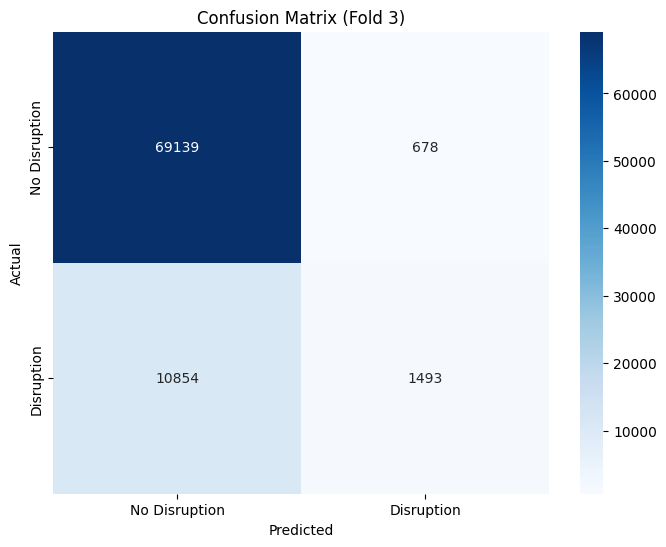


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Test Loss: 0.3592
Test Accuracy: 0.8529
Test Precision: 0.8529
Test Recall: 0.8529
Test F1 Score: 0.2061
Test Balanced Accuracy: 0.5551
Test AUC: 0.7866

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     69378
           1       0.64      0.12      0.21     12786

    accuracy                           0.85     82164
   macro avg       0.75      0.56      0.56     82164
weighted avg       0.83      0.85      0.81     82164



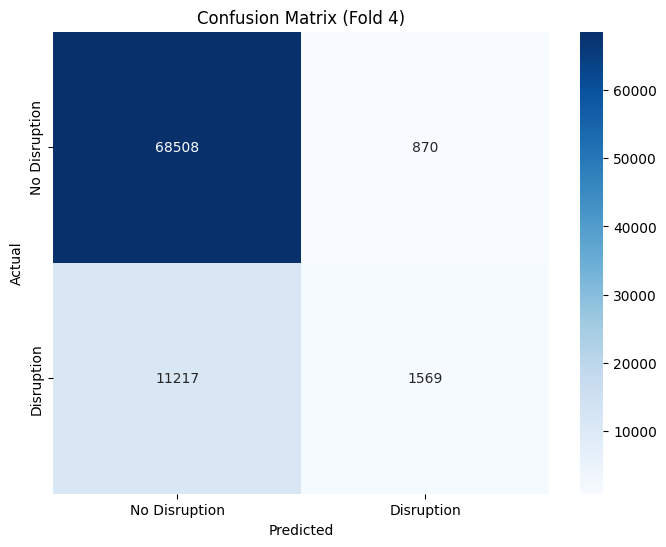


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Test Loss: 0.3251
Test Accuracy: 0.8792
Test Precision: 0.8792
Test Recall: 0.8792
Test F1 Score: 0.2477
Test Balanced Accuracy: 0.5704
Test AUC: 0.7938

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     71474
           1       0.65      0.15      0.25     10690

    accuracy                           0.88     82164
   macro avg       0.77      0.57      0.59     82164
weighted avg       0.86      0.88      0.85     82164



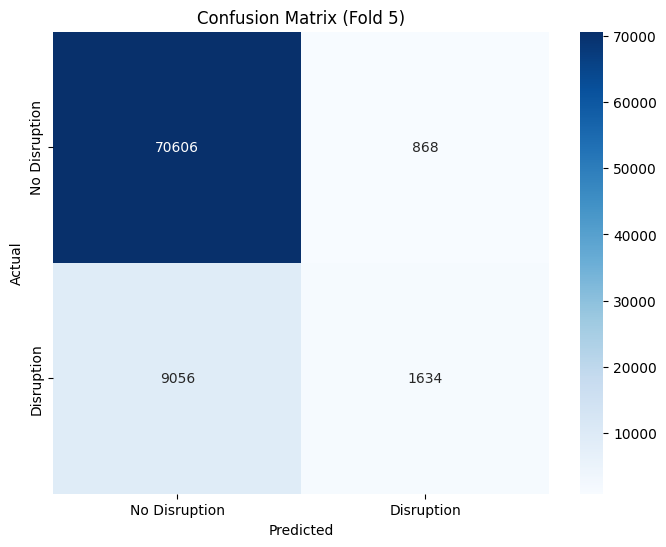


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Test Loss: 0.3255
Test Accuracy: 0.8835
Test Precision: 0.8835
Test Recall: 0.8835
Test F1 Score: 0.1681
Test Balanced Accuracy: 0.5432
Test AUC: 0.7643

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     73139
           1       0.39      0.11      0.17      9025

    accuracy                           0.88     82164
   macro avg       0.64      0.54      0.55     82164
weighted avg       0.84      0.88      0.85     82164



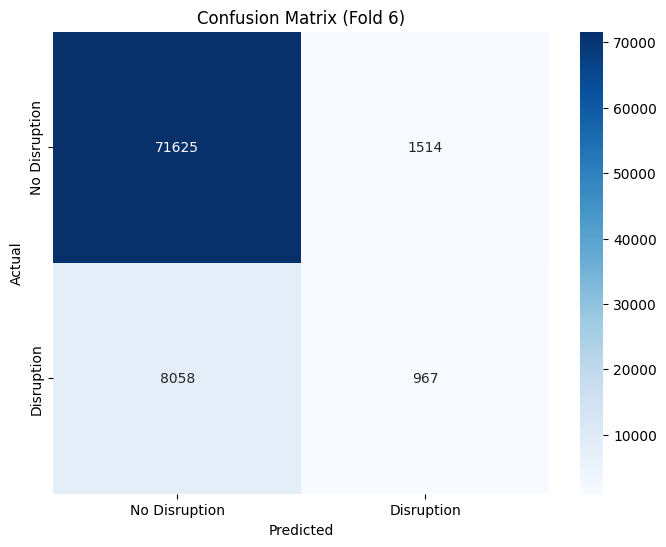


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8642 ± 0.0208
Precision: 0.8642 ± 0.0208
Recall: 0.8642 ± 0.0208
F1: 0.2006 ± 0.0247
Auc: 0.7827 ± 0.0181
Balanced_acc: 0.5540 ± 0.0084


({'accuracy': [0.8260552287101746,
   0.8839394450187683,
   0.8596465587615967,
   0.8528918027877808,
   0.8792171478271484,
   0.8835012912750244],
  'precision': [0.8260552287101746,
   0.8839394450187683,
   0.8596465587615967,
   0.8528918027877808,
   0.8792171478271484,
   0.8835012912750244],
  'recall': [0.8260552287101746,
   0.8839394450187683,
   0.8596465587615967,
   0.8528918027877808,
   0.8792171478271484,
   0.8835012912750244],
  'f1': [0.18813905930470348,
   0.1877342419080068,
   0.20567571290811407,
   0.20610837438423646,
   0.24772589448150395,
   0.1680862158873631],
  'auc': [0.7525241700545524,
   0.795834292107518,
   0.8028569131867804,
   0.78659258325245,
   0.7938309496152028,
   0.7643177255284297],
  'balanced_acc': [0.5488658091795271,
   0.5508410744077209,
   0.5556044798363915,
   0.555086171676653,
   0.5703544287647836,
   0.5432232520182513]},
 {'accuracy': 0.8642085790634155,
  'precision': 0.8642085790634155,
  'recall': 0.8642085790634155,


In [21]:
topo_reshaped = X_topo.reshape((X_topo.shape[0], X_topo.shape[1], 1))
topo_features = [ 
    'source_degree', 'source_weighted_degree', 'source_avg_distance', 
    'target_degree', 'target_weighted_degree', 'target_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index','weight', 'distance']
# Ensure the LSTM model is compatible with the reshaped input
final_model_topo, cv_metrics, feature_importance = cross_validate_lstm(
    X=topo_reshaped, 
    y=y, 
    features=topo_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(topo_reshaped, y, final_model_topo, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - AUC: 0.8888 - Precision: 0.8725 - Recall: 0.8725 - accuracy: 0.8725 - loss: 0.3859 - val_AUC: 0.9042 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3688
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - AUC: 0.9078 - Precision: 0.8713 - Recall: 0.8713 - accuracy: 0.8713 - loss: 0.3638 - val_AUC: 0.9302 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3364
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - AUC: 0.9213 - Precision: 0.8695 - Recall: 0.8695 - accuracy: 0.8695 - loss: 0.3486 - val_AUC: 0.9307 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3296
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - AUC: 0.9238 - Precision: 0.8703 - Recall: 0.8703 - accuracy: 0.8703 - loss: 0.3440 - val_AUC: 0.9313 - val_Precision: 0.8756 - val_Recall: 0.8756 - val_accuracy: 0.8756 - val_loss: 0.3285
Epoch 5/50
2055/2055 ━━━━━━

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

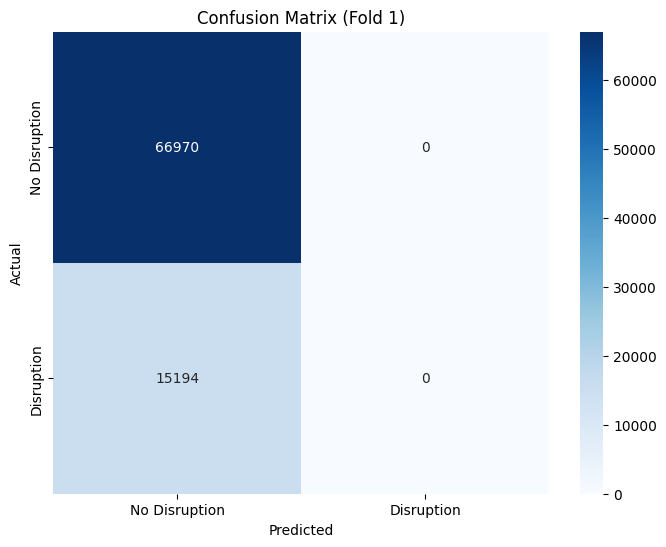


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 58s 13ms/step - AUC: 0.8605 - Precision: 0.8377 - Recall: 0.8377 - accuracy: 0.8377 - loss: 0.4403 - val_AUC: 0.9086 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3744
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - AUC: 0.8836 - Precision: 0.8385 - Recall: 0.8385 - accuracy: 0.8385 - loss: 0.4173 - val_AUC: 0.9239 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3533
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - AUC: 0.8898 - Precision: 0.8399 - Recall: 0.8399 - accuracy: 0.8399 - loss: 0.4094 - val_AUC: 0.9268 - val_Precision: 0.8667 - val_Recall: 0.8667 - val_accuracy: 0.8667 - val_loss: 0.3500
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 55s 13ms/step - AUC: 0.8915 - Precision: 0.8379 - Recall: 0.8379 - accuracy: 0.8379 - loss: 0.4090 - val_AUC: 0.9261 - val_Precision: 0.8645 - val_Recall: 0.8645 - val_accuracy: 0.8645 - val_loss: 0.3528
Epoch 5/50
4109/4109 ━━━━━━

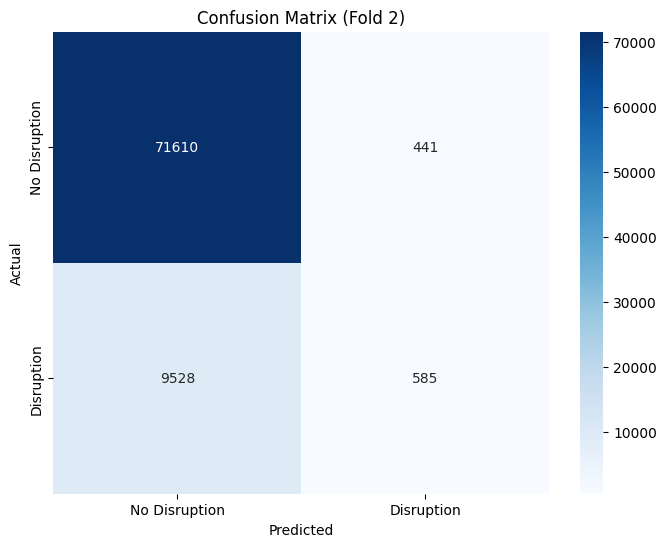


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - AUC: 0.8746 - Precision: 0.8472 - Recall: 0.8472 - accuracy: 0.8472 - loss: 0.4193 - val_AUC: 0.9430 - val_Precision: 0.8908 - val_Recall: 0.8908 - val_accuracy: 0.8908 - val_loss: 0.3027
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - AUC: 0.8984 - Precision: 0.8456 - Recall: 0.8456 - accuracy: 0.8456 - loss: 0.3954 - val_AUC: 0.9448 - val_Precision: 0.8924 - val_Recall: 0.8924 - val_accuracy: 0.8924 - val_loss: 0.2990
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - AUC: 0.9022 - Precision: 0.8492 - Recall: 0.8492 - accuracy: 0.8492 - loss: 0.3883 - val_AUC: 0.9449 - val_Precision: 0.8938 - val_Recall: 0.8938 - val_accuracy: 0.8938 - val_loss: 0.2973
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - AUC: 0.9037 - Precision: 0.8486 - Recall: 0.8486 - accuracy: 0.8486 - loss: 0.3866 - val_AUC: 0.9453 - val_Precision: 0.8925 - val_Recall: 0.8925 - val_accuracy: 0.8925 - val_loss: 0.3035
Epoch 5/50
6163/6163 ━━━━━━

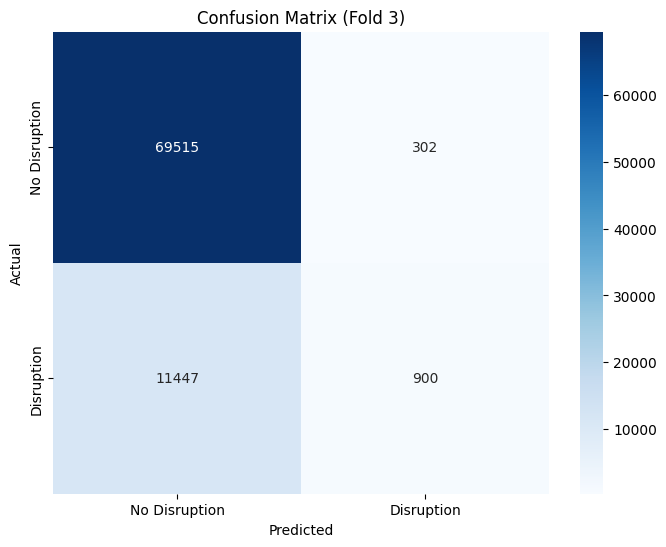


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 115s 14ms/step - AUC: 0.8857 - Precision: 0.8558 - Recall: 0.8558 - accuracy: 0.8558 - loss: 0.4019 - val_AUC: 0.9170 - val_Precision: 0.8524 - val_Recall: 0.8524 - val_accuracy: 0.8524 - val_loss: 0.3696
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 111s 14ms/step - AUC: 0.9074 - Precision: 0.8575 - Recall: 0.8575 - accuracy: 0.8575 - loss: 0.3765 - val_AUC: 0.9196 - val_Precision: 0.8530 - val_Recall: 0.8530 - val_accuracy: 0.8530 - val_loss: 0.3642
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 112s 14ms/step - AUC: 0.9095 - Precision: 0.8584 - Recall: 0.8584 - accuracy: 0.8584 - loss: 0.3729 - val_AUC: 0.9197 - val_Precision: 0.8532 - val_Recall: 0.8532 - val_accuracy: 0.8532 - val_loss: 0.3630
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 112s 14ms/step - AUC: 0.9123 - Precision: 0.8594 - Recall: 0.8594 - accuracy: 0.8594 - loss: 0.3683 - val_AUC: 0.9178 - val_Precision: 0.8511 - val_Recall: 0.8511 - val_accuracy: 0.8511 - val_loss: 0.3678
Epoch 5/50
8217/8217 ━━

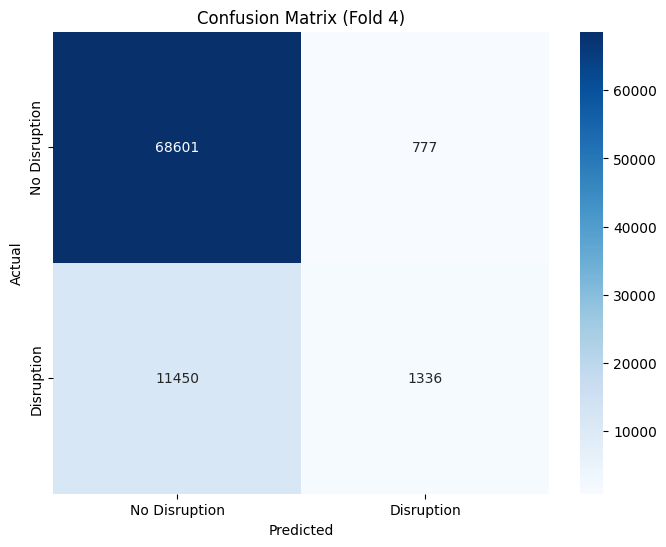


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 150s 14ms/step - AUC: 0.8894 - Precision: 0.8558 - Recall: 0.8558 - accuracy: 0.8558 - loss: 0.3985 - val_AUC: 0.9149 - val_Precision: 0.8485 - val_Recall: 0.8485 - val_accuracy: 0.8485 - val_loss: 0.3716
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 145s 14ms/step - AUC: 0.9109 - Precision: 0.8578 - Recall: 0.8578 - accuracy: 0.8578 - loss: 0.3714 - val_AUC: 0.9155 - val_Precision: 0.8484 - val_Recall: 0.8484 - val_accuracy: 0.8484 - val_loss: 0.3720
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 146s 14ms/step - AUC: 0.9119 - Precision: 0.8575 - Recall: 0.8575 - accuracy: 0.8575 - loss: 0.3699 - val_AUC: 0.9154 - val_Precision: 0.8491 - val_Recall: 0.8491 - val_accuracy: 0.8491 - val_loss: 0.3708
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 147s 14ms/step - AUC: 0.9132 - Precision: 0.8566 - Recall: 0.8566 - accuracy: 0.8566 - loss: 0.3684 - val_AUC: 0.9166 - val_Precision: 0.8488 - val_Recall: 0.8488 - val_accuracy: 0.8488 - val_loss: 0.3692
Epoch 5/50
1027

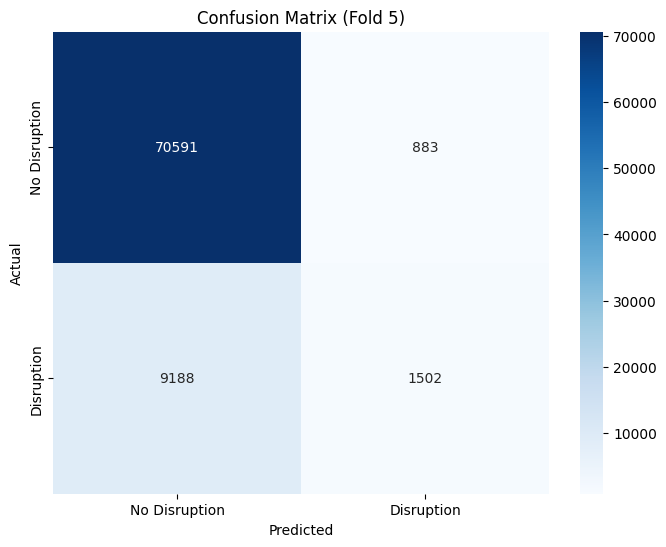


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 183s 15ms/step - AUC: 0.8884 - Precision: 0.8511 - Recall: 0.8511 - accuracy: 0.8511 - loss: 0.4028 - val_AUC: 0.9334 - val_Precision: 0.8749 - val_Recall: 0.8749 - val_accuracy: 0.8749 - val_loss: 0.3270
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 164s 13ms/step - AUC: 0.9114 - Precision: 0.8547 - Recall: 0.8547 - accuracy: 0.8547 - loss: 0.3725 - val_AUC: 0.9344 - val_Precision: 0.8757 - val_Recall: 0.8757 - val_accuracy: 0.8757 - val_loss: 0.3241
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 165s 13ms/step - AUC: 0.9133 - Precision: 0.8551 - Recall: 0.8551 - accuracy: 0.8551 - loss: 0.3693 - val_AUC: 0.9361 - val_Precision: 0.8781 - val_Recall: 0.8781 - val_accuracy: 0.8781 - val_loss: 0.3201
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 165s 13ms/step - AUC: 0.9153 - Precision: 0.8554 - Recall: 0.8554 - accuracy: 0.8554 - loss: 0.3658 - val_AUC: 0.9344 - val_Precision: 0.8771 - val_Recall: 0.8771 - val_accuracy: 0.8771 - val_loss: 0.3253
Epoch 5/50
1232

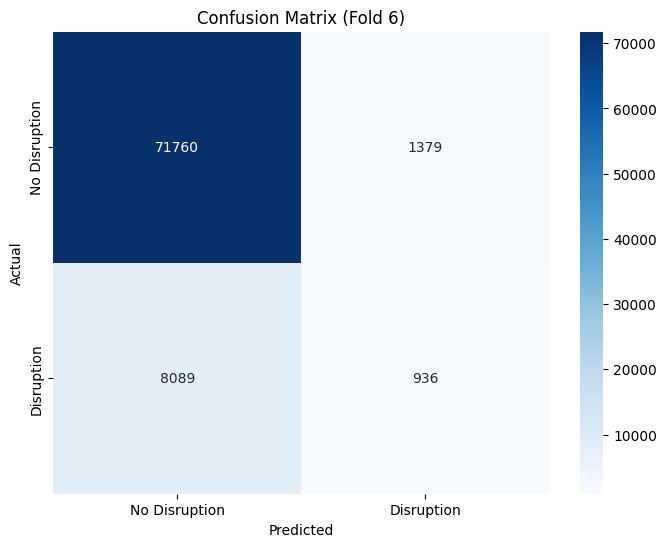


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8607 ± 0.0237
Precision: 0.8607 ± 0.0237
Recall: 0.8607 ± 0.0237
F1: 0.1353 ± 0.0719
Auc: 0.7366 ± 0.0551
Balanced_acc: 0.5355 ± 0.0198

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 2.1125
Test Accuracy: 0.6419
Test Precision: 0.6419
Test Recall: 0.6419
Test F1 Score: 0.2203
Test Balanced Accuracy: 0.4995
Test AUC: 0.4960

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77     66970
           1       0.18      0.27      0.22     15194

    accuracy                           0.64     82164
   macro avg       0.50      0.50      0.49     82164
weighted avg       0.70      0.64      0.67     82164



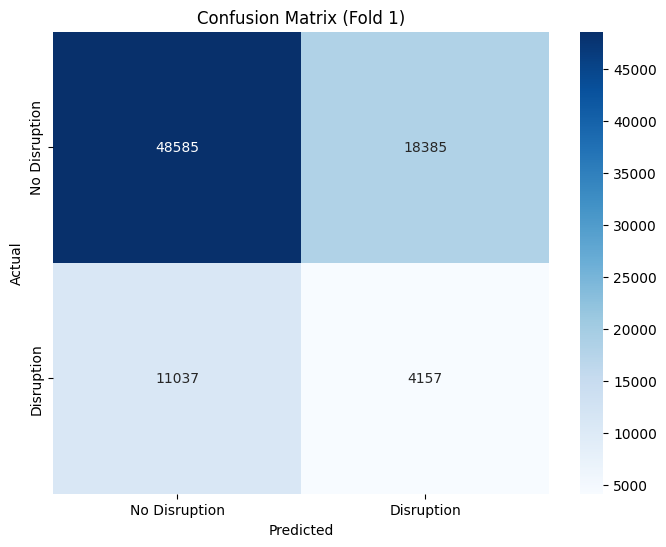


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 3.1364
Test Accuracy: 0.6690
Test Precision: 0.6690
Test Recall: 0.6690
Test F1 Score: 0.1752
Test Balanced Accuracy: 0.5042
Test AUC: 0.4878

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.72      0.79     72051
           1       0.13      0.29      0.18     10113

    accuracy                           0.67     82164
   macro avg       0.50      0.50      0.48     82164
weighted avg       0.79      0.67      0.72     82164



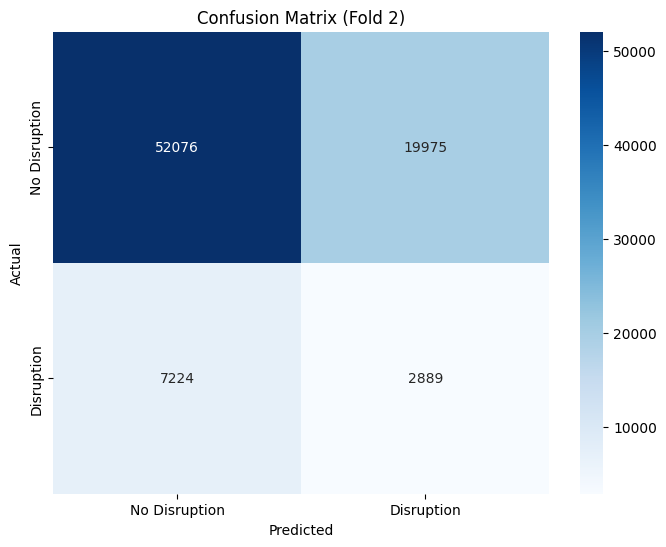


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 2.0038
Test Accuracy: 0.6565
Test Precision: 0.6565
Test Recall: 0.6565
Test F1 Score: 0.1894
Test Balanced Accuracy: 0.4962
Test AUC: 0.4932

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.73      0.78     69817
           1       0.15      0.27      0.19     12347

    accuracy                           0.66     82164
   macro avg       0.50      0.50      0.49     82164
weighted avg       0.74      0.66      0.69     82164



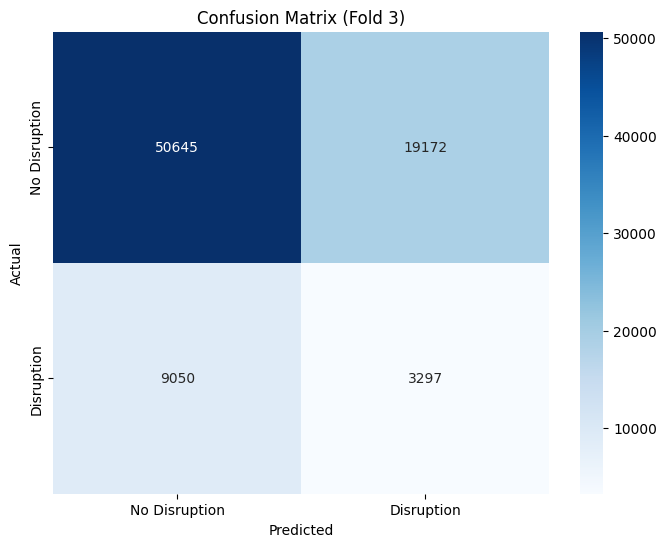


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 2.6521
Test Accuracy: 0.6703
Test Precision: 0.6703
Test Recall: 0.6703
Test F1 Score: 0.2190
Test Balanced Accuracy: 0.5181
Test AUC: 0.5288

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.74      0.79     69378
           1       0.17      0.30      0.22     12786

    accuracy                           0.67     82164
   macro avg       0.51      0.52      0.51     82164
weighted avg       0.75      0.67      0.70     82164



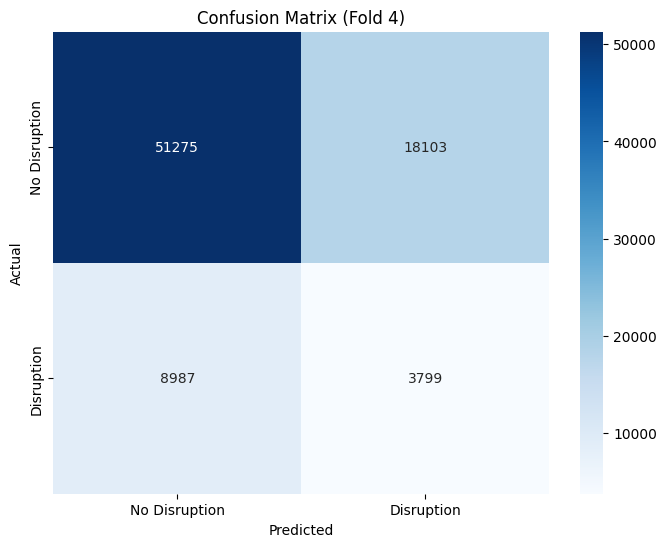


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 1.8405
Test Accuracy: 0.6972
Test Precision: 0.6972
Test Recall: 0.6972
Test F1 Score: 0.1529
Test Balanced Accuracy: 0.4901
Test AUC: 0.4846

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82     71474
           1       0.12      0.21      0.15     10690

    accuracy                           0.70     82164
   macro avg       0.49      0.49      0.48     82164
weighted avg       0.77      0.70      0.73     82164



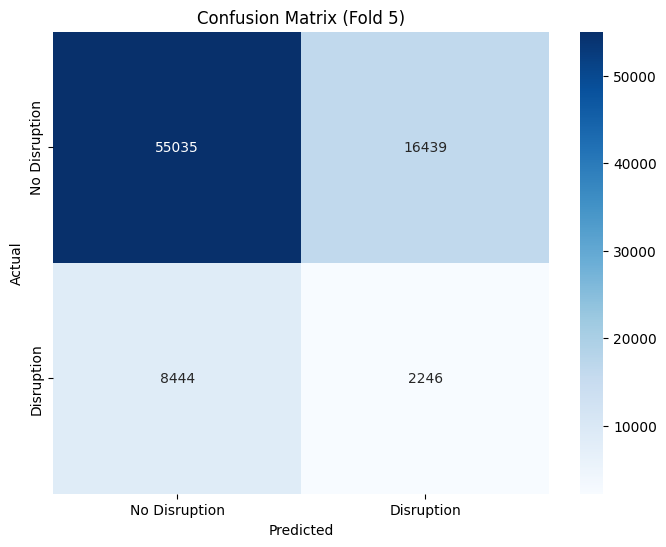


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Test Loss: 1.5900
Test Accuracy: 0.6648
Test Precision: 0.6648
Test Recall: 0.6648
Test F1 Score: 0.1590
Test Balanced Accuracy: 0.4999
Test AUC: 0.5010

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79     73139
           1       0.11      0.29      0.16      9025

    accuracy                           0.66     82164
   macro avg       0.50      0.50      0.47     82164
weighted avg       0.80      0.66      0.72     82164



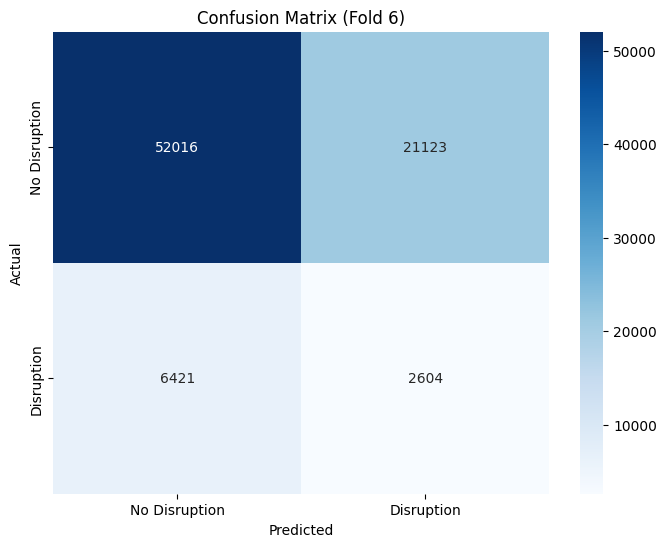


Cross-Validation Results (Mean ± Std):
Accuracy: 0.6666 ± 0.0167
Precision: 0.6666 ± 0.0167
Recall: 0.6666 ± 0.0167
F1: 0.1860 ± 0.0265
Auc: 0.4986 ± 0.0145
Balanced_acc: 0.5013 ± 0.0086


({'accuracy': [0.6419113278388977,
   0.6689669489860535,
   0.6565162539482117,
   0.6702935695648193,
   0.6971544623374939,
   0.6647680401802063],
  'precision': [0.6419113278388977,
   0.6689669489860535,
   0.6565162539482117,
   0.6702935695648193,
   0.6971544623374939,
   0.6647680401802063],
  'recall': [0.6419113278388977,
   0.6689669489860535,
   0.6565162539482117,
   0.6702935695648193,
   0.6971544623374939,
   0.6647680401802063],
  'f1': [0.22032011871952512,
   0.17521302726142463,
   0.18939568014705882,
   0.21903828413284132,
   0.1529191489361702,
   0.1590131900341964],
  'auc': [0.49600082868309203,
   0.487826357595734,
   0.4932221093026547,
   0.5287620809856474,
   0.4846228061815174,
   0.5009562128863346],
  'balanced_acc': [0.499534466472928,
   0.5042188630510457,
   0.4962124106933715,
   0.5180944957323341,
   0.4900515898642439,
   0.49986280515690934]},
 {'accuracy': 0.6666017671426138,
  'precision': 0.6666017671426138,
  'recall': 0.66660176714261

In [22]:
wthr_reshaped = X_wthr.reshape((X_wthr.shape[0], X_wthr.shape[1], 1))

# Ensure the LSTM model is compatible with the reshaped input
final_model_wthr, cv_metrics, feature_importance = cross_validate_lstm(
    X=topo_reshaped, 
    y=y, 
    features=wthr_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(wthr_reshaped, y, final_model_wthr, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - AUC: 0.9121 - Precision: 0.8721 - Recall: 0.8721 - accuracy: 0.8721 - loss: 0.3711 - val_AUC: 0.9386 - val_Precision: 0.8823 - val_Recall: 0.8823 - val_accuracy: 0.8823 - val_loss: 0.3249
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.9304 - Precision: 0.8738 - Recall: 0.8738 - accuracy: 0.8738 - loss: 0.3319 - val_AUC: 0.9357 - val_Precision: 0.8757 - val_Recall: 0.8757 - val_accuracy: 0.8757 - val_loss: 0.3252
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.9314 - Precision: 0.8771 - Recall: 0.8771 - accuracy: 0.8771 - loss: 0.3278 - val_AUC: 0.9393 - val_Precision: 0.8799 - val_Recall: 0.8799 - val_accuracy: 0.8799 - val_loss: 0.3292
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.9320 - Precision: 0.8762 - Recall: 0.8762 - accuracy: 0.8762 - loss: 0.3275 - val_AUC: 0.9363 - val_Precision: 0.8784 - val_Recall: 0.8784 - val_accuracy: 0.8784 - val_loss: 0.3283
Epoch 5/50
2055/2055 ━━━━━━━━━━

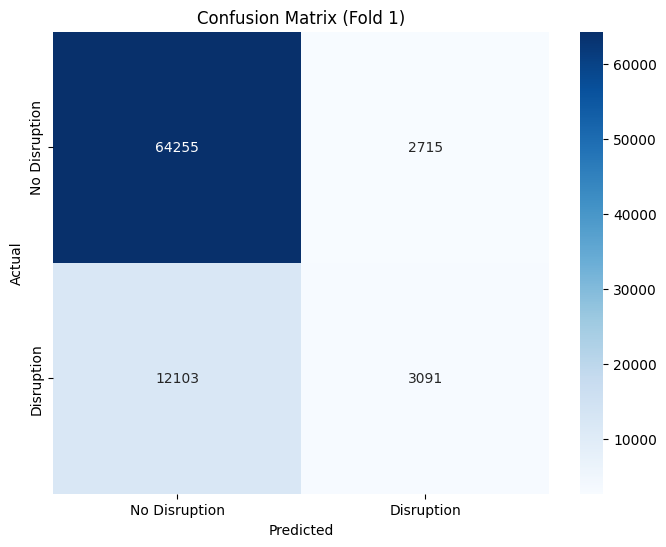


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - AUC: 0.9069 - Precision: 0.8409 - Recall: 0.8409 - accuracy: 0.8409 - loss: 0.3867 - val_AUC: 0.9070 - val_Precision: 0.8282 - val_Recall: 0.8282 - val_accuracy: 0.8282 - val_loss: 0.3923
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - AUC: 0.9235 - Precision: 0.8506 - Recall: 0.8506 - accuracy: 0.8506 - loss: 0.3516 - val_AUC: 0.9225 - val_Precision: 0.8443 - val_Recall: 0.8443 - val_accuracy: 0.8443 - val_loss: 0.3551
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - AUC: 0.9263 - Precision: 0.8542 - Recall: 0.8542 - accuracy: 0.8542 - loss: 0.3452 - val_AUC: 0.9170 - val_Precision: 0.8376 - val_Recall: 0.8376 - val_accuracy: 0.8376 - val_loss: 0.3768
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - AUC: 0.9252 - Precision: 0.8540 - Recall: 0.8540 - accuracy: 0.8540 - loss: 0.3475 - val_AUC: 0.9205 - val_Precision: 0.8420 - val_Recall: 0.8420 - val_accuracy: 0.8420 - val_loss: 0.3639
Epoch 5/50
4109/4109 ━━━━━━━━━━

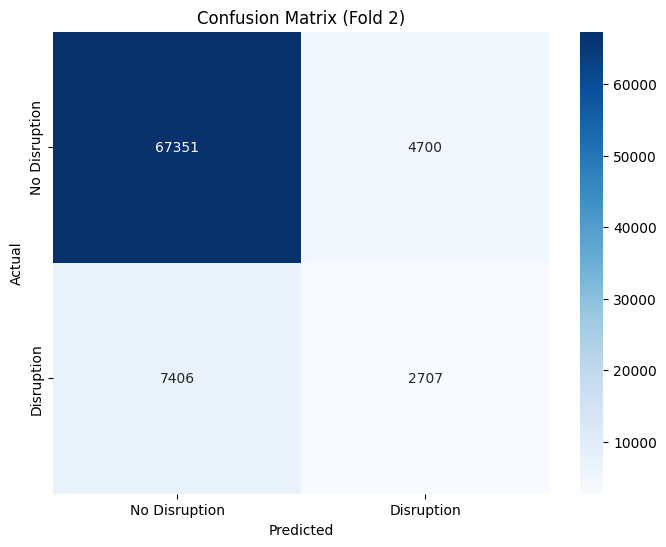


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - AUC: 0.9099 - Precision: 0.8454 - Recall: 0.8454 - accuracy: 0.8454 - loss: 0.3794 - val_AUC: 0.9421 - val_Precision: 0.8935 - val_Recall: 0.8935 - val_accuracy: 0.8935 - val_loss: 0.3093
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - AUC: 0.9247 - Precision: 0.8516 - Recall: 0.8516 - accuracy: 0.8516 - loss: 0.3487 - val_AUC: 0.9412 - val_Precision: 0.8795 - val_Recall: 0.8795 - val_accuracy: 0.8795 - val_loss: 0.3140
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - AUC: 0.9239 - Precision: 0.8512 - Recall: 0.8512 - accuracy: 0.8512 - loss: 0.3504 - val_AUC: 0.9357 - val_Precision: 0.8456 - val_Recall: 0.8456 - val_accuracy: 0.8456 - val_loss: 0.3211
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - AUC: 0.9260 - Precision: 0.8536 - Recall: 0.8536 - accuracy: 0.8536 - loss: 0.3455 - val_AUC: 0.9394 - val_Precision: 0.8821 - val_Recall: 0.8821 - val_accuracy: 0.8821 - val_loss: 0.3148
Epoch 5/50
6163/6163 ━━━━━━━━━━

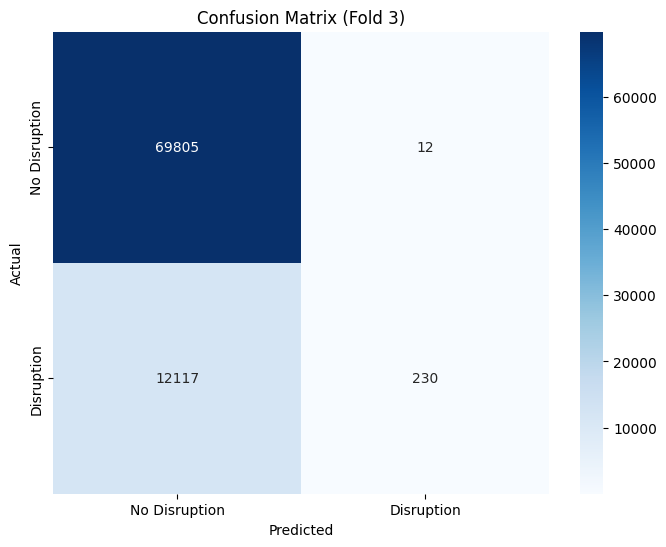


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - AUC: 0.9128 - Precision: 0.8553 - Recall: 0.8553 - accuracy: 0.8553 - loss: 0.3727 - val_AUC: 0.9104 - val_Precision: 0.8478 - val_Recall: 0.8478 - val_accuracy: 0.8478 - val_loss: 0.3790
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - AUC: 0.9270 - Precision: 0.8601 - Recall: 0.8601 - accuracy: 0.8601 - loss: 0.3432 - val_AUC: 0.9156 - val_Precision: 0.8506 - val_Recall: 0.8506 - val_accuracy: 0.8506 - val_loss: 0.3687
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - AUC: 0.9262 - Precision: 0.8577 - Recall: 0.8577 - accuracy: 0.8577 - loss: 0.3450 - val_AUC: 0.9098 - val_Precision: 0.8480 - val_Recall: 0.8480 - val_accuracy: 0.8480 - val_loss: 0.3787
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - AUC: 0.9278 - Precision: 0.8604 - Recall: 0.8604 - accuracy: 0.8604 - loss: 0.3410 - val_AUC: 0.9134 - val_Precision: 0.8476 - val_Recall: 0.8476 - val_accuracy: 0.8476 - val_loss: 0.3749
Epoch 5/50
8217/8217 ━━━━━━━━━━

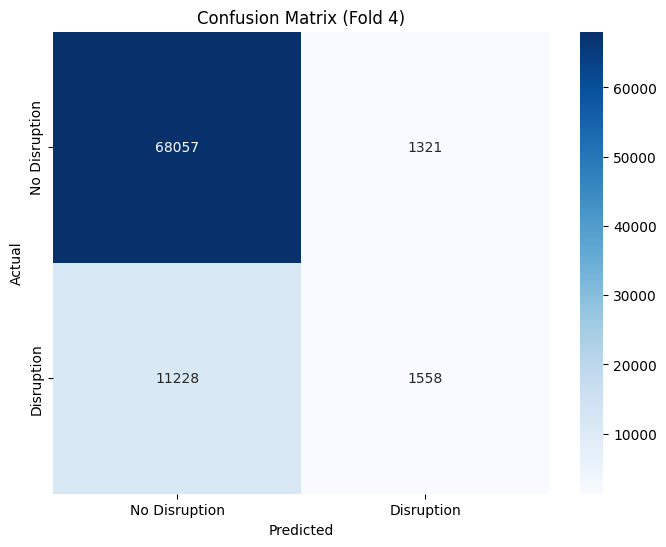


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 66s 6ms/step - AUC: 0.9128 - Precision: 0.8538 - Recall: 0.8538 - accuracy: 0.8538 - loss: 0.3722 - val_AUC: 0.9129 - val_Precision: 0.8512 - val_Recall: 0.8512 - val_accuracy: 0.8512 - val_loss: 0.3758
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 62s 6ms/step - AUC: 0.9228 - Precision: 0.8556 - Recall: 0.8556 - accuracy: 0.8556 - loss: 0.3526 - val_AUC: 0.9113 - val_Precision: 0.8498 - val_Recall: 0.8498 - val_accuracy: 0.8498 - val_loss: 0.3765
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - AUC: 0.9238 - Precision: 0.8560 - Recall: 0.8560 - accuracy: 0.8560 - loss: 0.3504 - val_AUC: 0.9086 - val_Precision: 0.8418 - val_Recall: 0.8418 - val_accuracy: 0.8418 - val_loss: 0.3883
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - AUC: 0.9240 - Precision: 0.8562 - Recall: 0.8562 - accuracy: 0.8562 - loss: 0.3499 - val_AUC: 0.9126 - val_Precision: 0.8511 - val_Recall: 0.8511 - val_accuracy: 0.8511 - val_loss: 0.3757
Epoch 5/50
10271/10271 

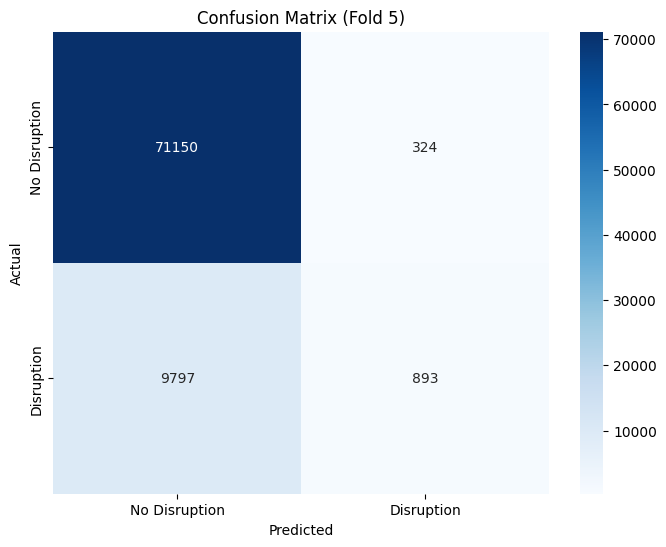


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - AUC: 0.9104 - Precision: 0.8520 - Recall: 0.8520 - accuracy: 0.8520 - loss: 0.3773 - val_AUC: 0.9283 - val_Precision: 0.8722 - val_Recall: 0.8722 - val_accuracy: 0.8722 - val_loss: 0.3484
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - AUC: 0.9194 - Precision: 0.8536 - Recall: 0.8536 - accuracy: 0.8536 - loss: 0.3597 - val_AUC: 0.9314 - val_Precision: 0.8780 - val_Recall: 0.8780 - val_accuracy: 0.8780 - val_loss: 0.3446
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - AUC: 0.9207 - Precision: 0.8542 - Recall: 0.8542 - accuracy: 0.8542 - loss: 0.3570 - val_AUC: 0.9296 - val_Precision: 0.8759 - val_Recall: 0.8759 - val_accuracy: 0.8759 - val_loss: 0.3327
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - AUC: 0.9209 - Precision: 0.8546 - Recall: 0.8546 - accuracy: 0.8546 - loss: 0.3565 - val_AUC: 0.9312 - val_Precision: 0.8760 - val_Recall: 0.8760 - val_accuracy: 0.8760 - val_loss: 0.3386
Epoch 5/50
12325/12325 

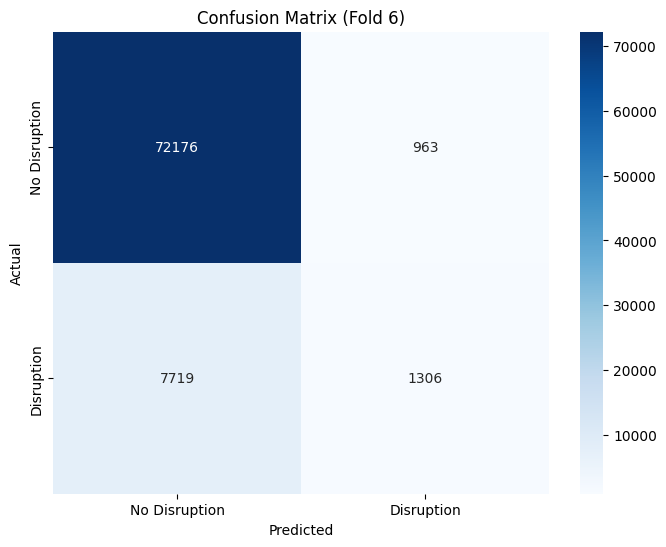


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8572 ± 0.0235
Precision: 0.8572 ± 0.0235
Recall: 0.8572 ± 0.0235
F1: 0.2034 ± 0.0921
Auc: 0.7630 ± 0.0110
Balanced_acc: 0.5581 ± 0.0296

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Loss: 0.4456
Test Accuracy: 0.8259
Test Precision: 0.8259
Test Recall: 0.8259
Test F1 Score: 0.4084
Test Balanced Accuracy: 0.6323
Test AUC: 0.8247

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     66970
           1       0.55      0.33      0.41     15194

    accuracy                           0.83     82164
   macro avg       0.70      0.63      0.65     82164
weighted avg       0.80      0.83      0.81     82164



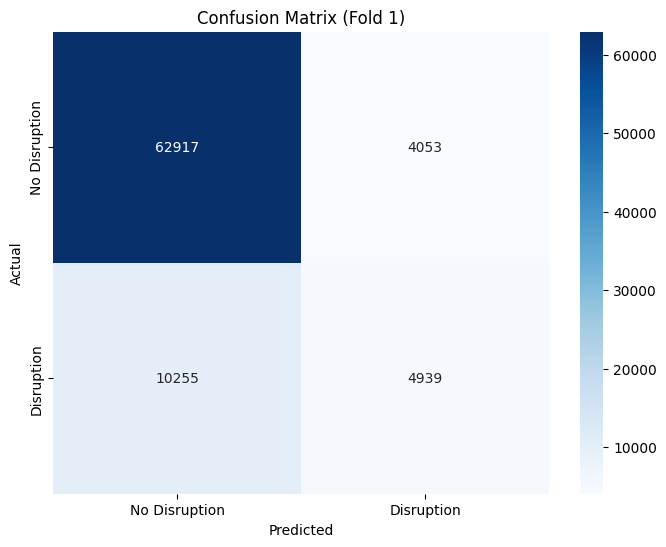


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Loss: 0.3959
Test Accuracy: 0.8596
Test Precision: 0.8596
Test Recall: 0.8596
Test F1 Score: 0.3071
Test Balanced Accuracy: 0.5988
Test AUC: 0.7722

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     72051
           1       0.39      0.25      0.31     10113

    accuracy                           0.86     82164
   macro avg       0.65      0.60      0.61     82164
weighted avg       0.84      0.86      0.85     82164



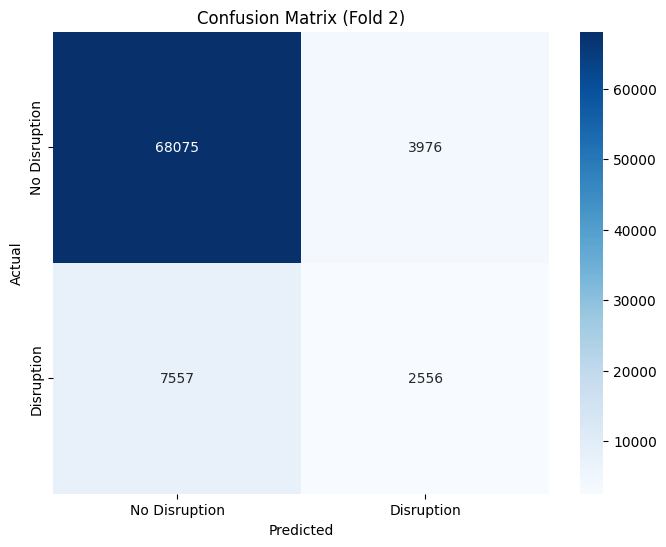


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Test Loss: 0.4497
Test Accuracy: 0.8330
Test Precision: 0.8330
Test Recall: 0.8330
Test F1 Score: 0.3208
Test Balanced Accuracy: 0.5982
Test AUC: 0.7493

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     69817
           1       0.41      0.26      0.32     12347

    accuracy                           0.83     82164
   macro avg       0.65      0.60      0.61     82164
weighted avg       0.81      0.83      0.82     82164



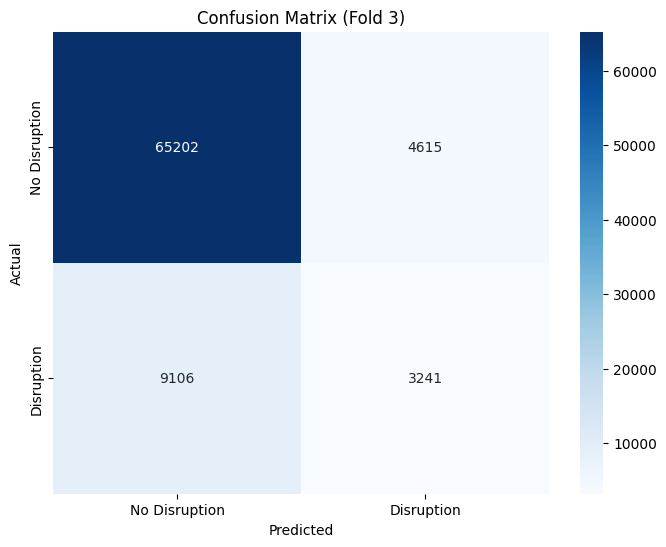


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Loss: 0.4423
Test Accuracy: 0.8321
Test Precision: 0.8321
Test Recall: 0.8321
Test F1 Score: 0.3149
Test Balanced Accuracy: 0.5939
Test AUC: 0.7505

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     69378
           1       0.43      0.25      0.31     12786

    accuracy                           0.83     82164
   macro avg       0.65      0.59      0.61     82164
weighted avg       0.80      0.83      0.81     82164



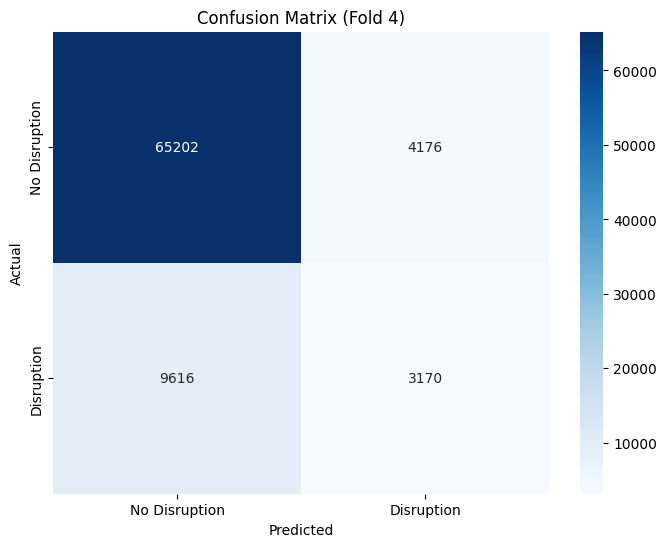


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Test Loss: 0.3683
Test Accuracy: 0.8706
Test Precision: 0.8706
Test Recall: 0.8706
Test F1 Score: 0.2566
Test Balanced Accuracy: 0.5734
Test AUC: 0.7616

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     71474
           1       0.51      0.17      0.26     10690

    accuracy                           0.87     82164
   macro avg       0.70      0.57      0.59     82164
weighted avg       0.84      0.87      0.84     82164



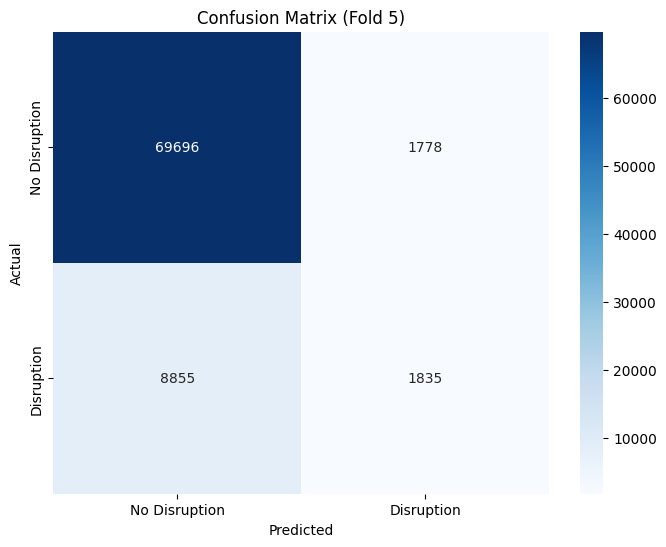


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Test Loss: 0.3273
Test Accuracy: 0.8943
Test Precision: 0.8943
Test Recall: 0.8943
Test F1 Score: 0.2313
Test Balanced Accuracy: 0.5658
Test AUC: 0.7773

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     73139
           1       0.58      0.14      0.23      9025

    accuracy                           0.89     82164
   macro avg       0.74      0.57      0.59     82164
weighted avg       0.87      0.89      0.87     82164



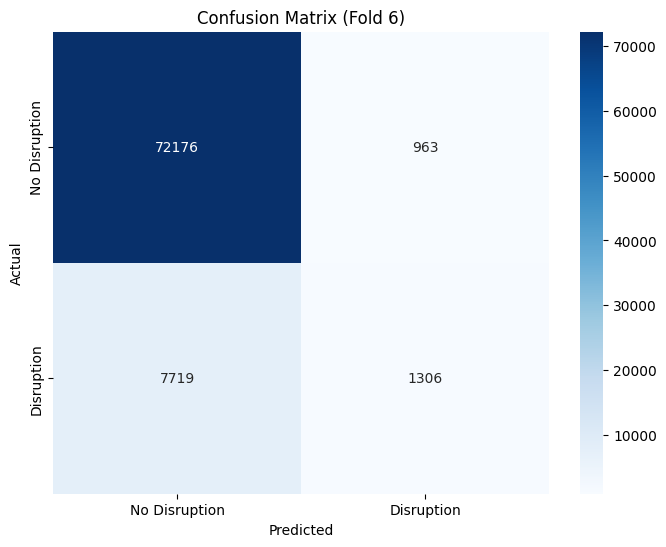


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8526 ± 0.0246
Precision: 0.8526 ± 0.0246
Recall: 0.8526 ± 0.0246
F1: 0.3065 ± 0.0560
Auc: 0.7726 ± 0.0254
Balanced_acc: 0.5937 ± 0.0213


({'accuracy': [0.8258605003356934,
   0.8596343994140625,
   0.8330047130584717,
   0.8321406245231628,
   0.8705880641937256,
   0.8943333029747009],
  'precision': [0.8258605003356934,
   0.8596343994140625,
   0.8330047130584717,
   0.8321406245231628,
   0.8705880641937256,
   0.8943333029747009],
  'recall': [0.8258605003356934,
   0.8596343994140625,
   0.8330047130584717,
   0.8321406245231628,
   0.8705880641937256,
   0.8943333029747009],
  'f1': [0.4084180931117175,
   0.307119255031541,
   0.32084343909320395,
   0.3149215179813233,
   0.256589526672726,
   0.23127324242960864],
  'auc': [0.8246558349060282,
   0.7721933735306149,
   0.7493396396639558,
   0.7505113530824322,
   0.7615795494383626,
   0.7773448545722468],
  'balanced_acc': [0.632271444511519,
   0.5987804293557992,
   0.5981957669690292,
   0.5938677144593214,
   0.5733897871449549,
   0.5657712156555088]},
 {'accuracy': 0.8525936007499695,
  'precision': 0.8525936007499695,
  'recall': 0.8525936007499695,
 

In [29]:
oper_reshaped = X_oper.reshape((X_oper.shape[0], X_oper.shape[1], 1))

final_model_oper, cv_metrics, feature_importance = cross_validate_lstm(
    X=oper_reshaped, 
    y=y, 
    features=oper_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(oper_reshaped, y, final_model_oper, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - AUC: 0.8871 - Precision: 0.8679 - Recall: 0.8679 - accuracy: 0.8679 - loss: 0.3928 - val_AUC: 0.8963 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3640
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - AUC: 0.8990 - Precision: 0.8716 - Recall: 0.8716 - accuracy: 0.8716 - loss: 0.3719 - val_AUC: 0.8974 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3688
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - AUC: 0.9056 - Precision: 0.8715 - Recall: 0.8715 - accuracy: 0.8715 - loss: 0.3650 - val_AUC: 0.9025 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3715
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - AUC: 0.9143 - Precision: 0.8735 - Recall: 0.8735 - accuracy: 0.8735 - loss: 0.3544 - val_AUC: 0.9117 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3586
Epoch 5/50
2055/2055 ━━━━━━

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

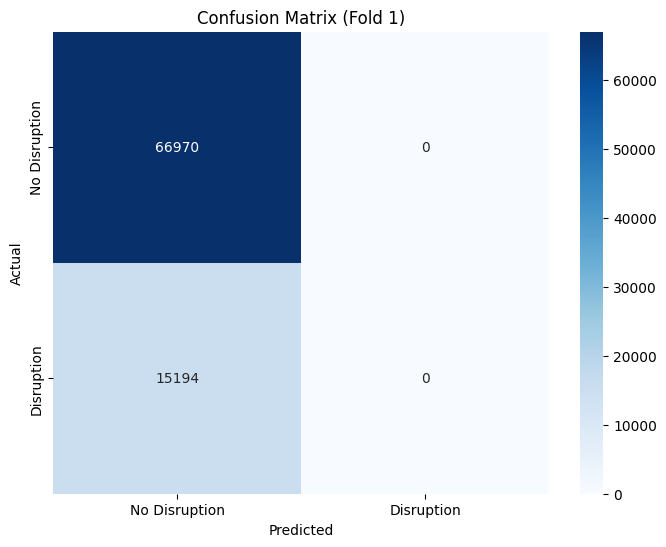


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 96s 23ms/step - AUC: 0.8605 - Precision: 0.8379 - Recall: 0.8379 - accuracy: 0.8379 - loss: 0.4389 - val_AUC: 0.8903 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3858
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 90s 22ms/step - AUC: 0.8801 - Precision: 0.8375 - Recall: 0.8375 - accuracy: 0.8375 - loss: 0.4214 - val_AUC: 0.9160 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3603
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 90s 22ms/step - AUC: 0.8927 - Precision: 0.8379 - Recall: 0.8379 - accuracy: 0.8379 - loss: 0.4075 - val_AUC: 0.9188 - val_Precision: 0.8650 - val_Recall: 0.8650 - val_accuracy: 0.8650 - val_loss: 0.3570
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 91s 22ms/step - AUC: 0.8976 - Precision: 0.8385 - Recall: 0.8385 - accuracy: 0.8385 - loss: 0.4008 - val_AUC: 0.9169 - val_Precision: 0.8641 - val_Recall: 0.8641 - val_accuracy: 0.8641 - val_loss: 0.3596
Epoch 5/50
4109/4109 ━━━━━━

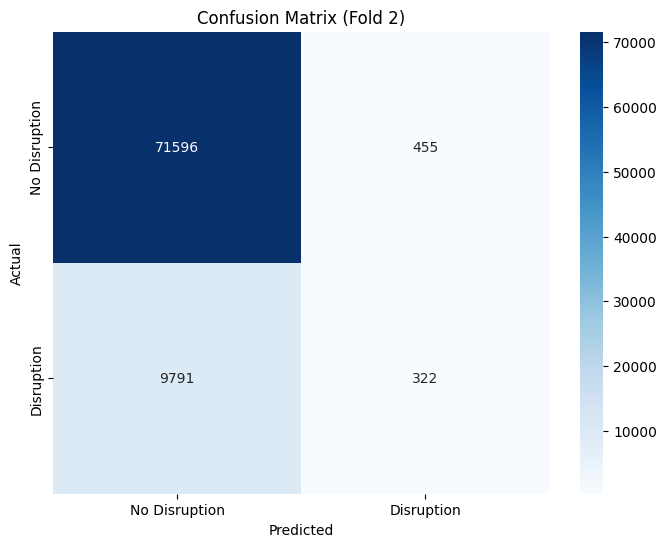


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 149s 24ms/step - AUC: 0.8675 - Precision: 0.8459 - Recall: 0.8459 - accuracy: 0.8459 - loss: 0.4256 - val_AUC: 0.9101 - val_Precision: 0.8908 - val_Recall: 0.8908 - val_accuracy: 0.8908 - val_loss: 0.3432
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 143s 23ms/step - AUC: 0.8875 - Precision: 0.8457 - Recall: 0.8457 - accuracy: 0.8457 - loss: 0.4072 - val_AUC: 0.9327 - val_Precision: 0.8905 - val_Recall: 0.8905 - val_accuracy: 0.8905 - val_loss: 0.3174
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 144s 23ms/step - AUC: 0.9038 - Precision: 0.8480 - Recall: 0.8480 - accuracy: 0.8480 - loss: 0.3870 - val_AUC: 0.9380 - val_Precision: 0.8919 - val_Recall: 0.8919 - val_accuracy: 0.8919 - val_loss: 0.3067
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 146s 24ms/step - AUC: 0.9071 - Precision: 0.8484 - Recall: 0.8484 - accuracy: 0.8484 - loss: 0.3823 - val_AUC: 0.9391 - val_Precision: 0.8915 - val_Recall: 0.8915 - val_accuracy: 0.8915 - val_loss: 0.3112
Epoch 5/50
6163/6163 ━━

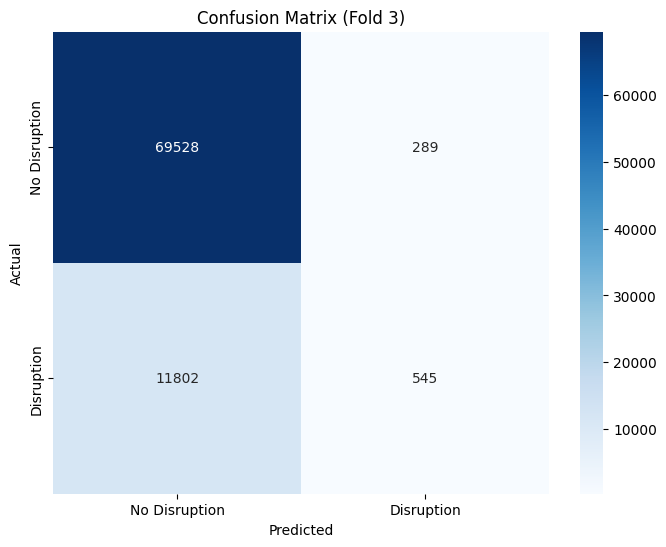


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 207s 25ms/step - AUC: 0.8749 - Precision: 0.8548 - Recall: 0.8548 - accuracy: 0.8548 - loss: 0.4141 - val_AUC: 0.9000 - val_Precision: 0.8466 - val_Recall: 0.8466 - val_accuracy: 0.8466 - val_loss: 0.3949
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 202s 25ms/step - AUC: 0.9071 - Precision: 0.8549 - Recall: 0.8549 - accuracy: 0.8549 - loss: 0.3785 - val_AUC: 0.9085 - val_Precision: 0.8467 - val_Recall: 0.8467 - val_accuracy: 0.8467 - val_loss: 0.3812
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 204s 25ms/step - AUC: 0.9139 - Precision: 0.8564 - Recall: 0.8564 - accuracy: 0.8564 - loss: 0.3676 - val_AUC: 0.9097 - val_Precision: 0.8478 - val_Recall: 0.8478 - val_accuracy: 0.8478 - val_loss: 0.3786
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 205s 25ms/step - AUC: 0.9165 - Precision: 0.8575 - Recall: 0.8575 - accuracy: 0.8575 - loss: 0.3631 - val_AUC: 0.9095 - val_Precision: 0.8505 - val_Recall: 0.8505 - val_accuracy: 0.8505 - val_loss: 0.3807
Epoch 5/50
8217/8217 ━━

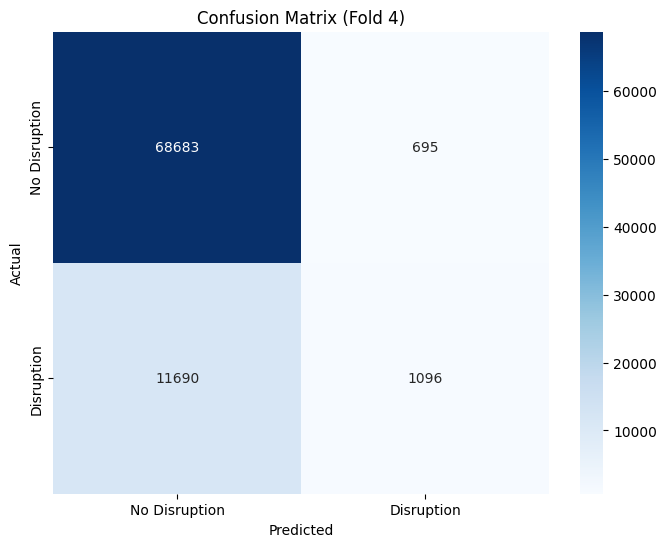


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 281s 27ms/step - AUC: 0.8766 - Precision: 0.8535 - Recall: 0.8535 - accuracy: 0.8535 - loss: 0.4108 - val_AUC: 0.9098 - val_Precision: 0.8444 - val_Recall: 0.8444 - val_accuracy: 0.8444 - val_loss: 0.3808
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 276s 27ms/step - AUC: 0.9112 - Precision: 0.8547 - Recall: 0.8547 - accuracy: 0.8547 - loss: 0.3725 - val_AUC: 0.9120 - val_Precision: 0.8466 - val_Recall: 0.8466 - val_accuracy: 0.8466 - val_loss: 0.3752
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 280s 27ms/step - AUC: 0.9152 - Precision: 0.8561 - Recall: 0.8561 - accuracy: 0.8561 - loss: 0.3660 - val_AUC: 0.9089 - val_Precision: 0.8475 - val_Recall: 0.8475 - val_accuracy: 0.8475 - val_loss: 0.3816
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 282s 27ms/step - AUC: 0.9173 - Precision: 0.8578 - Recall: 0.8578 - accuracy: 0.8578 - loss: 0.3615 - val_AUC: 0.9119 - val_Precision: 0.8487 - val_Recall: 0.8487 - val_accuracy: 0.8487 - val_loss: 0.3811
Epoch 5/50
1027

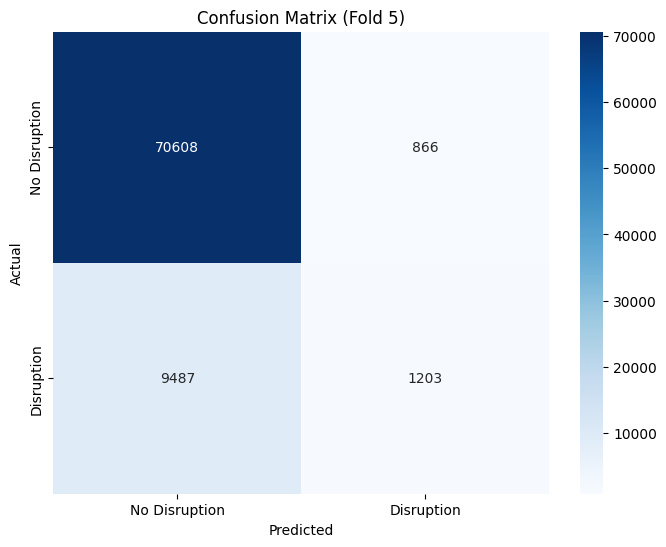


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 372s 30ms/step - AUC: 0.8763 - Precision: 0.8500 - Recall: 0.8500 - accuracy: 0.8500 - loss: 0.4141 - val_AUC: 0.9255 - val_Precision: 0.8718 - val_Recall: 0.8718 - val_accuracy: 0.8718 - val_loss: 0.3411
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 43345s 4s/step - AUC: 0.9104 - Precision: 0.8538 - Recall: 0.8538 - accuracy: 0.8538 - loss: 0.3744 - val_AUC: 0.9304 - val_Precision: 0.8737 - val_Recall: 0.8737 - val_accuracy: 0.8737 - val_loss: 0.3306
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 373s 30ms/step - AUC: 0.9138 - Precision: 0.8545 - Recall: 0.8545 - accuracy: 0.8545 - loss: 0.3687 - val_AUC: 0.9327 - val_Precision: 0.8735 - val_Recall: 0.8735 - val_accuracy: 0.8735 - val_loss: 0.3275
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 380s 31ms/step - AUC: 0.9157 - Precision: 0.8547 - Recall: 0.8547 - accuracy: 0.8547 - loss: 0.3656 - val_AUC: 0.9341 - val_Precision: 0.8746 - val_Recall: 0.8746 - val_accuracy: 0.8746 - val_loss: 0.3251
Epoch 5/50
1232

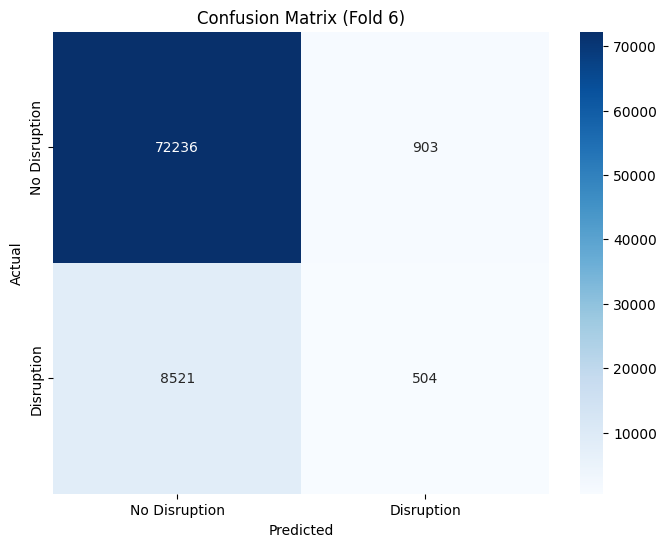


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8586 ± 0.0233
Precision: 0.8586 ± 0.0233
Recall: 0.8586 ± 0.0233
F1: 0.0962 ± 0.0609
Auc: 0.7190 ± 0.0627
Balanced_acc: 0.5238 ± 0.0163

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.4039
Test Accuracy: 0.8246
Test Precision: 0.8246
Test Recall: 0.8246
Test F1 Score: 0.1362
Test Balanced Accuracy: 0.5348
Test AUC: 0.7778

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     66970
           1       0.76      0.07      0.14     15194

    accuracy                           0.82     82164
   macro avg       0.80      0.53      0.52     82164
weighted avg       0.81      0.82      0.76     82164



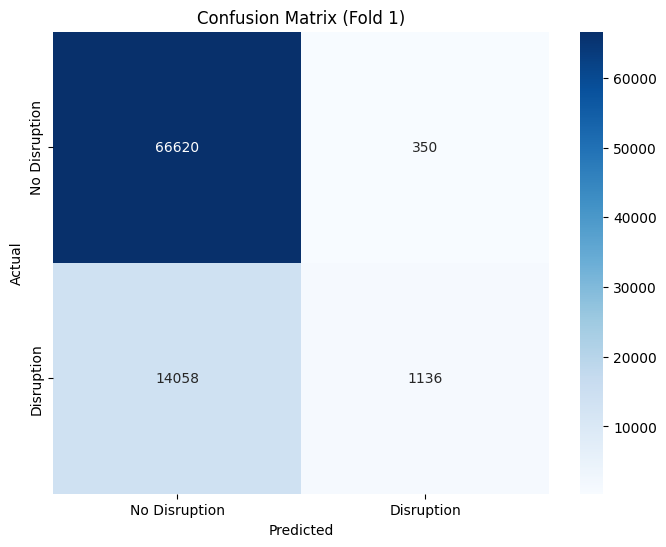


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
Test Loss: 0.2957
Test Accuracy: 0.8890
Test Precision: 0.8890
Test Recall: 0.8890
Test F1 Score: 0.2396
Test Balanced Accuracy: 0.5679
Test AUC: 0.8117

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     72051
           1       0.77      0.14      0.24     10113

    accuracy                           0.89     82164
   macro avg       0.83      0.57      0.59     82164
weighted avg       0.88      0.89      0.85     82164



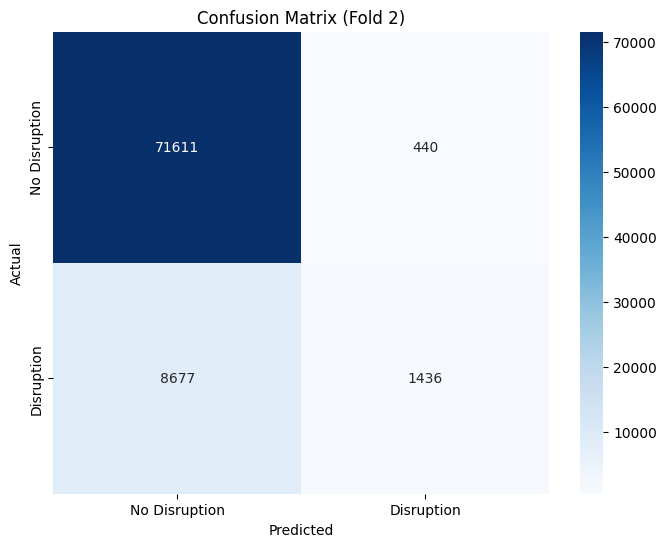


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.3491
Test Accuracy: 0.8587
Test Precision: 0.8587
Test Recall: 0.8587
Test F1 Score: 0.1576
Test Balanced Accuracy: 0.5415
Test AUC: 0.7875

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     69817
           1       0.76      0.09      0.16     12347

    accuracy                           0.86     82164
   macro avg       0.81      0.54      0.54     82164
weighted avg       0.85      0.86      0.81     82164



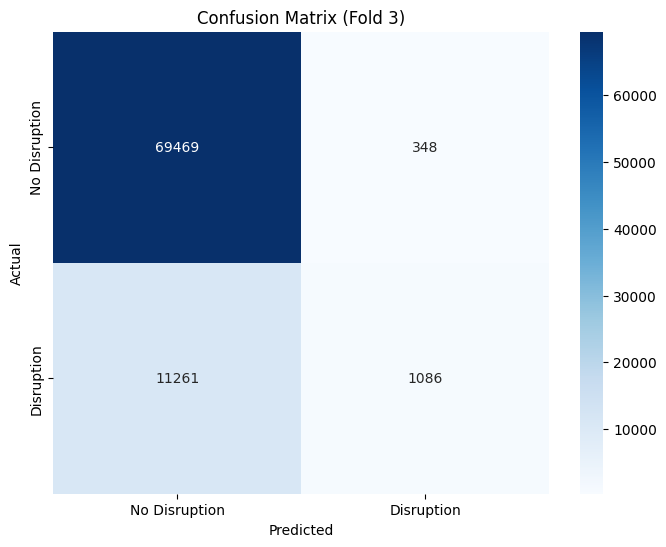


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
Test Loss: 0.3636
Test Accuracy: 0.8531
Test Precision: 0.8531
Test Recall: 0.8531
Test F1 Score: 0.1728
Test Balanced Accuracy: 0.5454
Test AUC: 0.7745

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     69378
           1       0.70      0.10      0.17     12786

    accuracy                           0.85     82164
   macro avg       0.78      0.55      0.55     82164
weighted avg       0.83      0.85      0.80     82164



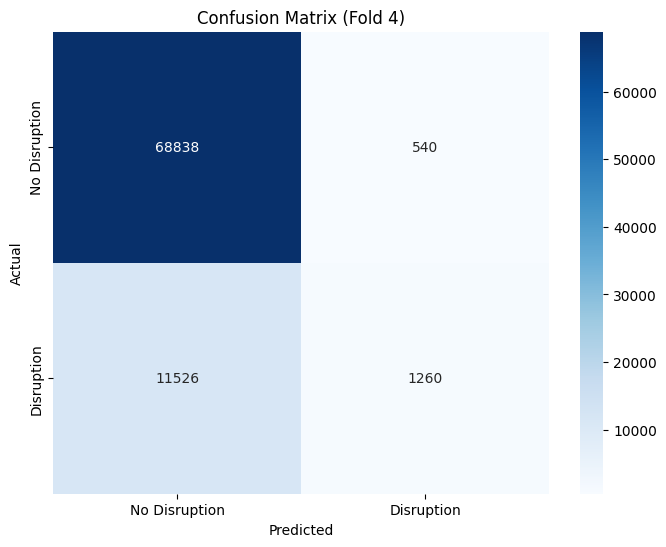


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.3261
Test Accuracy: 0.8762
Test Precision: 0.8762
Test Recall: 0.8762
Test F1 Score: 0.1811
Test Balanced Accuracy: 0.5484
Test AUC: 0.7793

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     71474
           1       0.65      0.11      0.18     10690

    accuracy                           0.88     82164
   macro avg       0.77      0.55      0.56     82164
weighted avg       0.85      0.88      0.84     82164



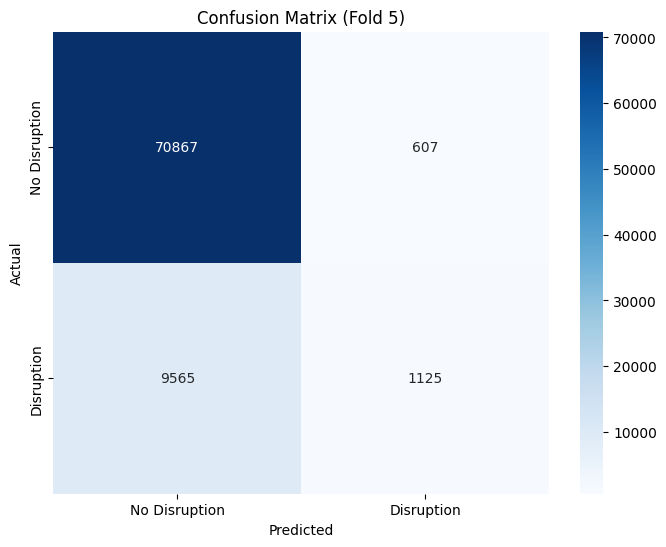


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.3143
Test Accuracy: 0.8853
Test Precision: 0.8853
Test Recall: 0.8853
Test F1 Score: 0.0966
Test Balanced Accuracy: 0.5217
Test AUC: 0.7507

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     73139
           1       0.36      0.06      0.10      9025

    accuracy                           0.89     82164
   macro avg       0.63      0.52      0.52     82164
weighted avg       0.84      0.89      0.85     82164



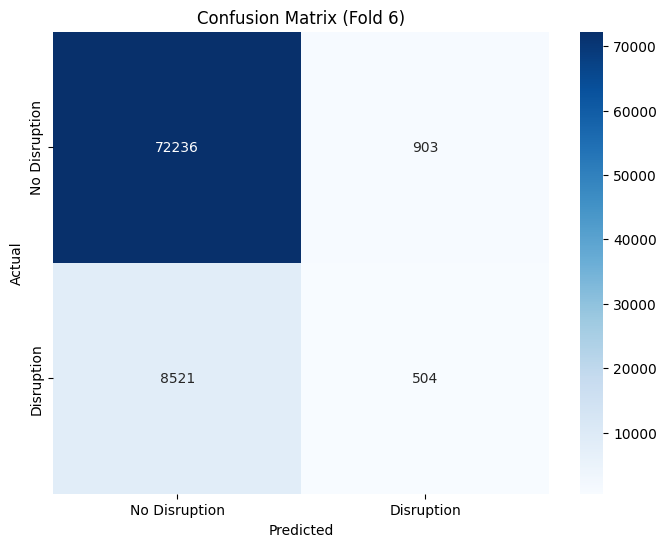


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8645 ± 0.0221
Precision: 0.8645 ± 0.0221
Recall: 0.8645 ± 0.0221
F1: 0.1640 ± 0.0436
Auc: 0.7803 ± 0.0180
Balanced_acc: 0.5433 ± 0.0140


({'accuracy': [0.8246433734893799,
   0.8890389800071716,
   0.8587093949317932,
   0.8531473875045776,
   0.8761988282203674,
   0.8853025436401367],
  'precision': [0.8246433734893799,
   0.8890389800071716,
   0.8587093949317932,
   0.8531473875045776,
   0.8761988282203674,
   0.8853025436401367],
  'recall': [0.8246433734893799,
   0.8890389800071716,
   0.8587093949317932,
   0.8531473875045776,
   0.8761988282203674,
   0.8853025436401367],
  'f1': [0.13621103117505995,
   0.23955292351322044,
   0.15760830128437703,
   0.17276840806252572,
   0.18113025277733055,
   0.09662576687116564],
  'auc': [0.7778442766863973,
   0.8117106298691548,
   0.7874589742328826,
   0.7744589696814685,
   0.7793090080209454,
   0.7507334317583501],
  'balanced_acc': [0.5347700672221765,
   0.5679443329638935,
   0.541486064636328,
   0.5453809183509936,
   0.5483729709925068,
   0.521749260571994]},
 {'accuracy': 0.8645067512989044,
  'precision': 0.8645067512989044,
  'recall': 0.86450675129890

In [30]:
tnw_reshaped = X_tnw.reshape((X_tnw.shape[0], X_tnw.shape[1], 1))

final_model_tnw, cv_metrics, feature_importance = cross_validate_lstm(
    X=tnw_reshaped, 
    y=y, 
    features=wthr_features + topo_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(tnw_reshaped, y, final_model_tnw, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - AUC: 0.8876 - Precision: 0.8698 - Recall: 0.8698 - accuracy: 0.8698 - loss: 0.3918 - val_AUC: 0.9029 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3620
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 54s 26ms/step - AUC: 0.9033 - Precision: 0.8721 - Recall: 0.8721 - accuracy: 0.8721 - loss: 0.3659 - val_AUC: 0.9059 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3627
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 52s 26ms/step - AUC: 0.9089 - Precision: 0.8719 - Recall: 0.8719 - accuracy: 0.8719 - loss: 0.3610 - val_AUC: 0.9157 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3507
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 53s 26ms/step - AUC: 0.9198 - Precision: 0.8717 - Recall: 0.8717 - accuracy: 0.8717 - loss: 0.3486 - val_AUC: 0.9378 - val_Precision: 0.8775 - val_Recall: 0.8775 - val_accuracy: 0.8775 - val_loss: 0.3202
Epoch 5/50
2055/2055 ━━━━━━

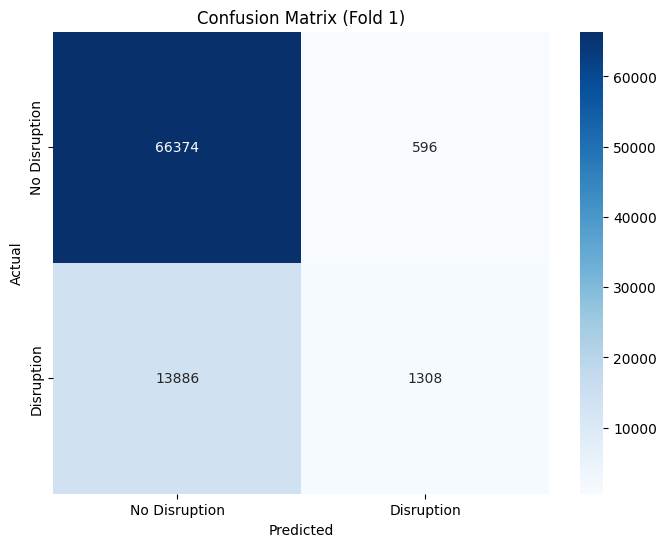


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 109s 26ms/step - AUC: 0.8645 - Precision: 0.8393 - Recall: 0.8393 - accuracy: 0.8393 - loss: 0.4361 - val_AUC: 0.9204 - val_Precision: 0.8354 - val_Recall: 0.8354 - val_accuracy: 0.8354 - val_loss: 0.3744
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - AUC: 0.9147 - Precision: 0.8415 - Recall: 0.8415 - accuracy: 0.8415 - loss: 0.3713 - val_AUC: 0.9259 - val_Precision: 0.8486 - val_Recall: 0.8486 - val_accuracy: 0.8486 - val_loss: 0.3506
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - AUC: 0.9237 - Precision: 0.8491 - Recall: 0.8491 - accuracy: 0.8491 - loss: 0.3519 - val_AUC: 0.9169 - val_Precision: 0.8237 - val_Recall: 0.8237 - val_accuracy: 0.8237 - val_loss: 0.3672
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 108s 26ms/step - AUC: 0.9281 - Precision: 0.8566 - Recall: 0.8566 - accuracy: 0.8566 - loss: 0.3414 - val_AUC: 0.9234 - val_Precision: 0.8375 - val_Recall: 0.8375 - val_accuracy: 0.8375 - val_loss: 0.3541
Epoch 5/50
4109/4109 ━━

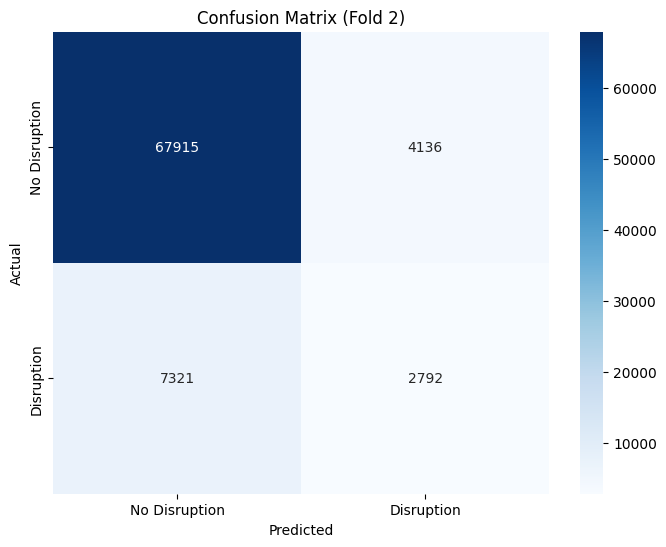


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 169s 27ms/step - AUC: 0.8751 - Precision: 0.8459 - Recall: 0.8459 - accuracy: 0.8459 - loss: 0.4183 - val_AUC: 0.9470 - val_Precision: 0.8929 - val_Recall: 0.8929 - val_accuracy: 0.8929 - val_loss: 0.2950
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 164s 27ms/step - AUC: 0.9198 - Precision: 0.8487 - Recall: 0.8487 - accuracy: 0.8487 - loss: 0.3606 - val_AUC: 0.9434 - val_Precision: 0.8812 - val_Recall: 0.8812 - val_accuracy: 0.8812 - val_loss: 0.3128
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 164s 27ms/step - AUC: 0.9268 - Precision: 0.8540 - Recall: 0.8540 - accuracy: 0.8540 - loss: 0.3448 - val_AUC: 0.9488 - val_Precision: 0.8934 - val_Recall: 0.8934 - val_accuracy: 0.8934 - val_loss: 0.2980
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 166s 27ms/step - AUC: 0.9289 - Precision: 0.8555 - Recall: 0.8555 - accuracy: 0.8555 - loss: 0.3401 - val_AUC: 0.9427 - val_Precision: 0.8690 - val_Recall: 0.8690 - val_accuracy: 0.8690 - val_loss: 0.3089
Epoch 5/50
6163/6163 ━━

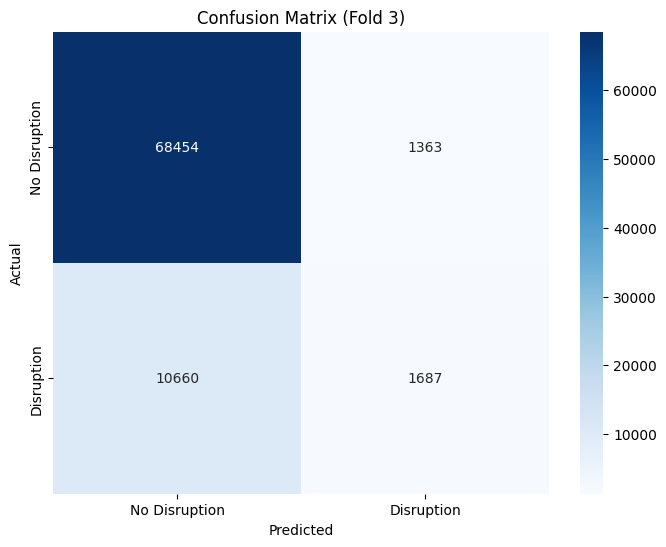


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 227s 27ms/step - AUC: 0.8851 - Precision: 0.8557 - Recall: 0.8557 - accuracy: 0.8557 - loss: 0.4015 - val_AUC: 0.9207 - val_Precision: 0.8526 - val_Recall: 0.8526 - val_accuracy: 0.8526 - val_loss: 0.3615
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 220s 27ms/step - AUC: 0.9256 - Precision: 0.8592 - Recall: 0.8592 - accuracy: 0.8592 - loss: 0.3463 - val_AUC: 0.9214 - val_Precision: 0.8542 - val_Recall: 0.8542 - val_accuracy: 0.8542 - val_loss: 0.3589
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 219s 27ms/step - AUC: 0.9298 - Precision: 0.8595 - Recall: 0.8595 - accuracy: 0.8595 - loss: 0.3375 - val_AUC: 0.9212 - val_Precision: 0.8516 - val_Recall: 0.8516 - val_accuracy: 0.8516 - val_loss: 0.3581
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 220s 27ms/step - AUC: 0.9326 - Precision: 0.8627 - Recall: 0.8627 - accuracy: 0.8627 - loss: 0.3310 - val_AUC: 0.9246 - val_Precision: 0.8528 - val_Recall: 0.8528 - val_accuracy: 0.8528 - val_loss: 0.3506
Epoch 5/50
8217/8217 ━━

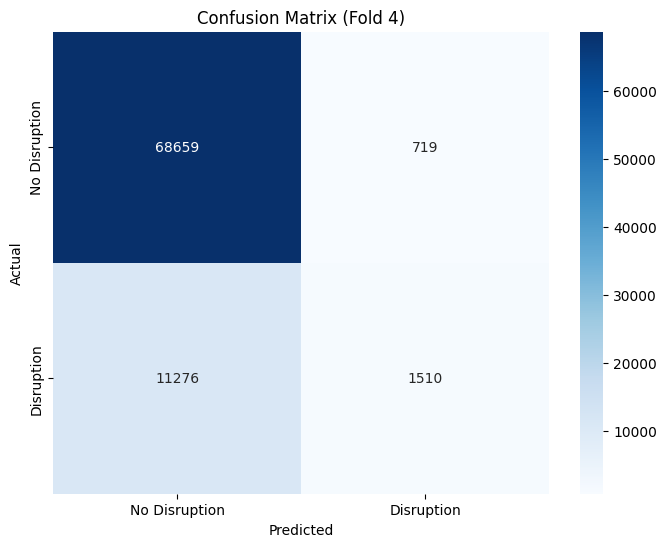


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 312s 30ms/step - AUC: 0.8993 - Precision: 0.8546 - Recall: 0.8546 - accuracy: 0.8546 - loss: 0.3864 - val_AUC: 0.9193 - val_Precision: 0.8530 - val_Recall: 0.8530 - val_accuracy: 0.8530 - val_loss: 0.3607
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 302s 29ms/step - AUC: 0.9259 - Precision: 0.8577 - Recall: 0.8577 - accuracy: 0.8577 - loss: 0.3462 - val_AUC: 0.9204 - val_Precision: 0.8513 - val_Recall: 0.8513 - val_accuracy: 0.8513 - val_loss: 0.3593
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 300s 29ms/step - AUC: 0.9298 - Precision: 0.8583 - Recall: 0.8583 - accuracy: 0.8583 - loss: 0.3378 - val_AUC: 0.9218 - val_Precision: 0.8527 - val_Recall: 0.8527 - val_accuracy: 0.8527 - val_loss: 0.3566
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 301s 29ms/step - AUC: 0.9313 - Precision: 0.8601 - Recall: 0.8601 - accuracy: 0.8601 - loss: 0.3343 - val_AUC: 0.9216 - val_Precision: 0.8496 - val_Recall: 0.8496 - val_accuracy: 0.8496 - val_loss: 0.3576
Epoch 5/50
1027

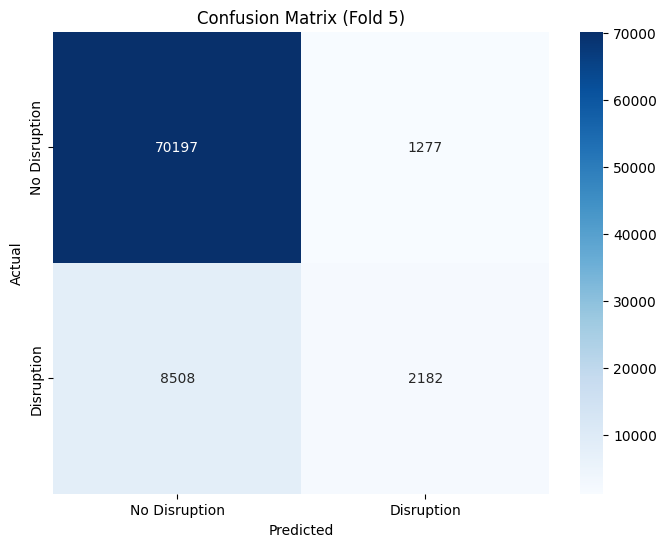


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 382s 31ms/step - AUC: 0.9044 - Precision: 0.8522 - Recall: 0.8522 - accuracy: 0.8522 - loss: 0.3813 - val_AUC: 0.9388 - val_Precision: 0.8820 - val_Recall: 0.8820 - val_accuracy: 0.8820 - val_loss: 0.3166
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 378s 31ms/step - AUC: 0.9264 - Precision: 0.8556 - Recall: 0.8556 - accuracy: 0.8556 - loss: 0.3456 - val_AUC: 0.9398 - val_Precision: 0.8761 - val_Recall: 0.8761 - val_accuracy: 0.8761 - val_loss: 0.3153
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 377s 31ms/step - AUC: 0.9307 - Precision: 0.8592 - Recall: 0.8592 - accuracy: 0.8592 - loss: 0.3356 - val_AUC: 0.9418 - val_Precision: 0.8839 - val_Recall: 0.8839 - val_accuracy: 0.8839 - val_loss: 0.3051
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 381s 31ms/step - AUC: 0.9316 - Precision: 0.8607 - Recall: 0.8607 - accuracy: 0.8607 - loss: 0.3333 - val_AUC: 0.9421 - val_Precision: 0.8807 - val_Recall: 0.8807 - val_accuracy: 0.8807 - val_loss: 0.3090
Epoch 5/50
1232

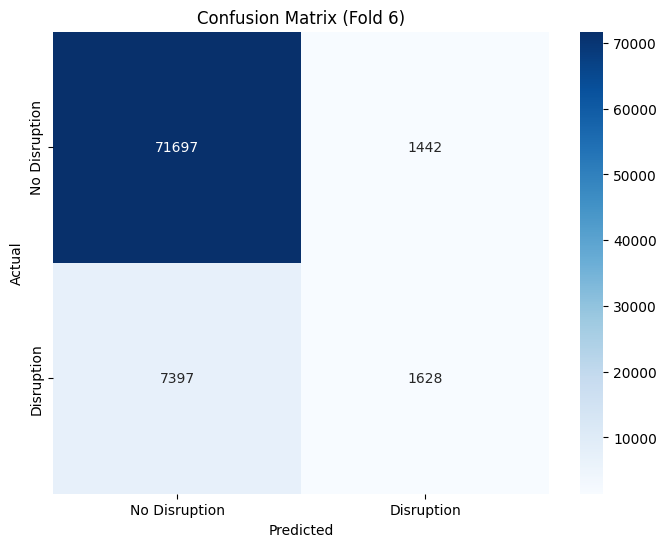


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8609 ± 0.0219
Precision: 0.8609 ± 0.0219
Recall: 0.8609 ± 0.0219
F1: 0.2464 ± 0.0612
Auc: 0.7901 ± 0.0200
Balanced_acc: 0.5723 ± 0.0243

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.4079
Test Accuracy: 0.8199
Test Precision: 0.8199
Test Recall: 0.8199
Test F1 Score: 0.1757
Test Balanced Accuracy: 0.5431
Test AUC: 0.7770

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     66970
           1       0.57      0.10      0.18     15194

    accuracy                           0.82     82164
   macro avg       0.70      0.54      0.54     82164
weighted avg       0.78      0.82      0.77     82164



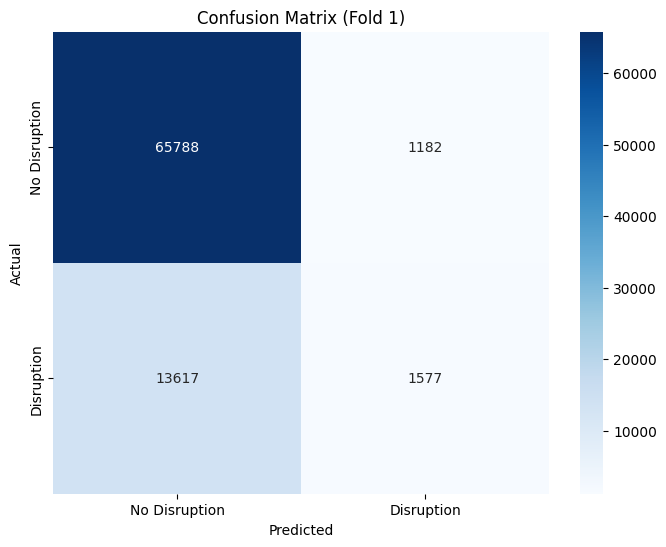


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3098
Test Accuracy: 0.8828
Test Precision: 0.8828
Test Recall: 0.8828
Test F1 Score: 0.2178
Test Balanced Accuracy: 0.5603
Test AUC: 0.8093

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     72051
           1       0.61      0.13      0.22     10113

    accuracy                           0.88     82164
   macro avg       0.75      0.56      0.58     82164
weighted avg       0.86      0.88      0.85     82164



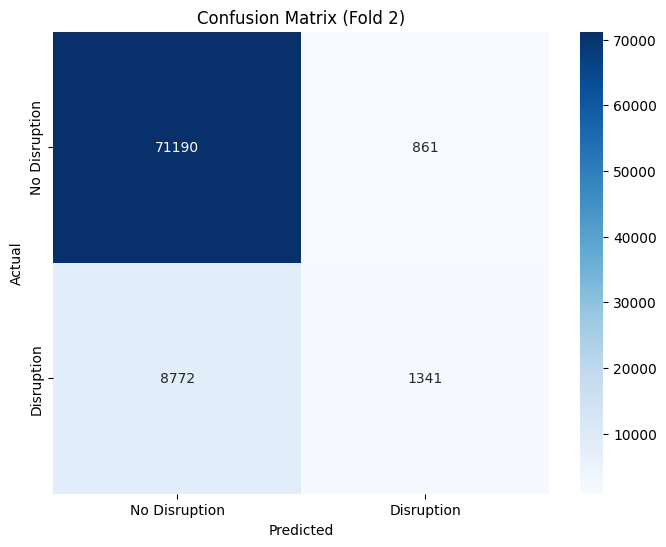


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3368
Test Accuracy: 0.8613
Test Precision: 0.8613
Test Recall: 0.8613
Test F1 Score: 0.2517
Test Balanced Accuracy: 0.5707
Test AUC: 0.8093

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.92     69817
           1       0.66      0.16      0.25     12347

    accuracy                           0.86     82164
   macro avg       0.77      0.57      0.59     82164
weighted avg       0.84      0.86      0.82     82164



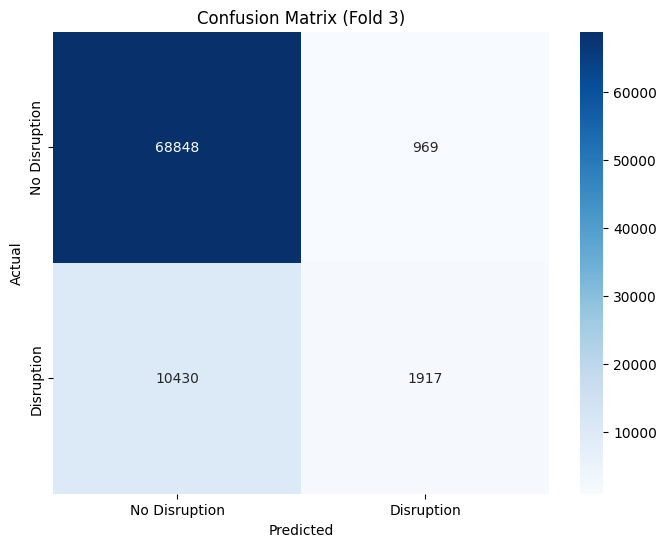


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3432
Test Accuracy: 0.8574
Test Precision: 0.8574
Test Recall: 0.8574
Test F1 Score: 0.2788
Test Balanced Accuracy: 0.5800
Test AUC: 0.8093

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     69378
           1       0.65      0.18      0.28     12786

    accuracy                           0.86     82164
   macro avg       0.76      0.58      0.60     82164
weighted avg       0.83      0.86      0.82     82164



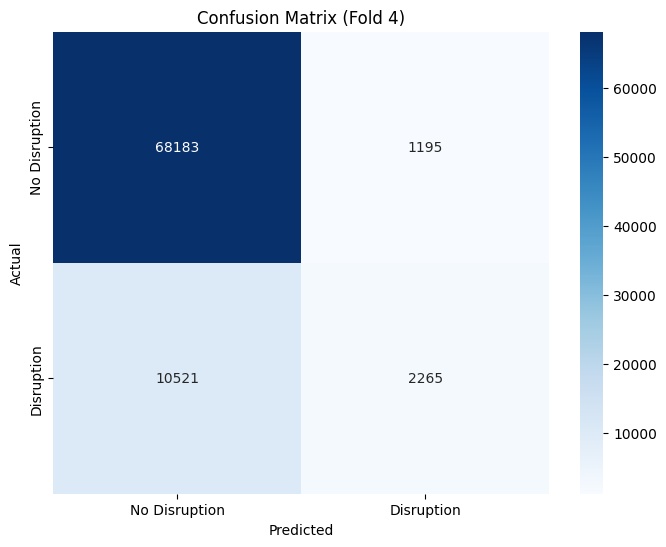


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3055
Test Accuracy: 0.8828
Test Precision: 0.8828
Test Recall: 0.8828
Test F1 Score: 0.3007
Test Balanced Accuracy: 0.5898
Test AUC: 0.8137

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     71474
           1       0.67      0.19      0.30     10690

    accuracy                           0.88     82164
   macro avg       0.78      0.59      0.62     82164
weighted avg       0.86      0.88      0.85     82164



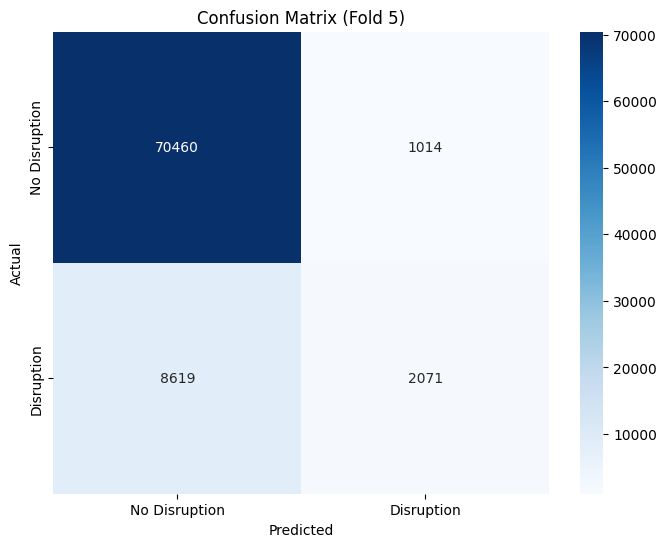


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.2879
Test Accuracy: 0.8924
Test Precision: 0.8924
Test Recall: 0.8924
Test F1 Score: 0.2692
Test Balanced Accuracy: 0.5803
Test AUC: 0.8045

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     73139
           1       0.53      0.18      0.27      9025

    accuracy                           0.89     82164
   macro avg       0.72      0.58      0.61     82164
weighted avg       0.87      0.89      0.87     82164



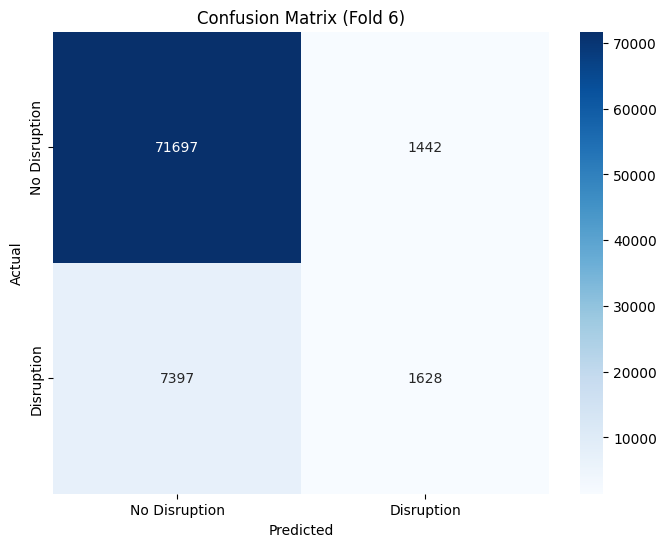


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8661 ± 0.0241
Precision: 0.8661 ± 0.0241
Recall: 0.8661 ± 0.0241
F1: 0.2490 ± 0.0415
Auc: 0.8039 ± 0.0123
Balanced_acc: 0.5707 ± 0.0153


({'accuracy': [0.8198845982551575,
   0.8827588558197021,
   0.8612653017044067,
   0.8574071526527405,
   0.8827588558197021,
   0.8924224972724915],
  'precision': [0.8198845982551575,
   0.8827588558197021,
   0.8612653017044067,
   0.8574071526527405,
   0.8827588558197021,
   0.8924224972724915],
  'recall': [0.8198845982551575,
   0.8827588558197021,
   0.8612653017044067,
   0.8574071526527405,
   0.8827588558197021,
   0.8924224972724915],
  'f1': [0.17568094468890993,
   0.21778319123020706,
   0.2516904089805029,
   0.27883786778283887,
   0.3006896551724138,
   0.2692021496486151],
  'auc': [0.7769867259949853,
   0.809337138047932,
   0.8093326892834216,
   0.8093450056092035,
   0.8136962611143204,
   0.804508743435781],
  'balanced_acc': [0.5430706381134982,
   0.5603258665278217,
   0.5706906229775984,
   0.5799611995082563,
   0.5897727415803212,
   0.5803359640897787]},
 {'accuracy': 0.8660828769207001,
  'precision': 0.8660828769207001,
  'recall': 0.8660828769207001,

In [32]:
tno_reshaped = X_tno.reshape((X_tno.shape[0], X_tno.shape[1], 1))

final_model_tno, cv_metrics, feature_importance = cross_validate_lstm(
    X=tno_reshaped, 
    y=y, 
    features= topo_features + oper_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(tno_reshaped, y, final_model_tno, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - AUC: 0.8866 - Precision: 0.8705 - Recall: 0.8705 - accuracy: 0.8705 - loss: 0.3872 - val_AUC: 0.9322 - val_Precision: 0.8742 - val_Recall: 0.8742 - val_accuracy: 0.8742 - val_loss: 0.3665
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - AUC: 0.9287 - Precision: 0.8721 - Recall: 0.8721 - accuracy: 0.8721 - loss: 0.3355 - val_AUC: 0.9288 - val_Precision: 0.8695 - val_Recall: 0.8695 - val_accuracy: 0.8695 - val_loss: 0.3744
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - AUC: 0.9344 - Precision: 0.8742 - Recall: 0.8742 - accuracy: 0.8742 - loss: 0.3236 - val_AUC: 0.9220 - val_Precision: 0.8507 - val_Recall: 0.8507 - val_accuracy: 0.8507 - val_loss: 0.3775
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - AUC: 0.9340 - Precision: 0.8743 - Recall: 0.8743 - accuracy: 0.8743 - loss: 0.3245 - val_AUC: 0.9254 - val_Precision: 0.8579 - val_Recall: 0.8579 - val_accuracy: 0.8579 - val_loss: 0.3690
Epoch 5/50
2055/2055 ━━━━━━

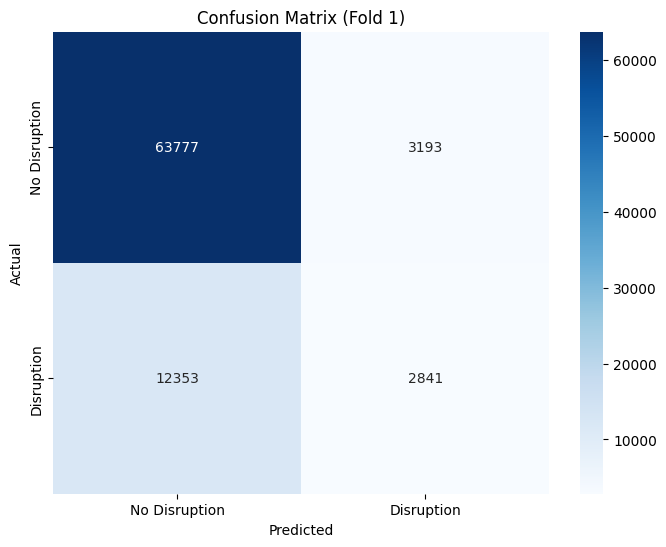


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 85s 20ms/step - AUC: 0.8861 - Precision: 0.8413 - Recall: 0.8413 - accuracy: 0.8413 - loss: 0.4098 - val_AUC: 0.9101 - val_Precision: 0.8324 - val_Recall: 0.8324 - val_accuracy: 0.8324 - val_loss: 0.3849
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 81s 20ms/step - AUC: 0.9209 - Precision: 0.8501 - Recall: 0.8501 - accuracy: 0.8501 - loss: 0.3578 - val_AUC: 0.9142 - val_Precision: 0.8362 - val_Recall: 0.8362 - val_accuracy: 0.8362 - val_loss: 0.3731
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 82s 20ms/step - AUC: 0.9236 - Precision: 0.8555 - Recall: 0.8555 - accuracy: 0.8555 - loss: 0.3513 - val_AUC: 0.9020 - val_Precision: 0.8234 - val_Recall: 0.8234 - val_accuracy: 0.8234 - val_loss: 0.3965
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 81s 20ms/step - AUC: 0.9254 - Precision: 0.8595 - Recall: 0.8595 - accuracy: 0.8595 - loss: 0.3466 - val_AUC: 0.8993 - val_Precision: 0.8178 - val_Recall: 0.8178 - val_accuracy: 0.8178 - val_loss: 0.4018
Epoch 5/50
4109/4109 ━━━━━━

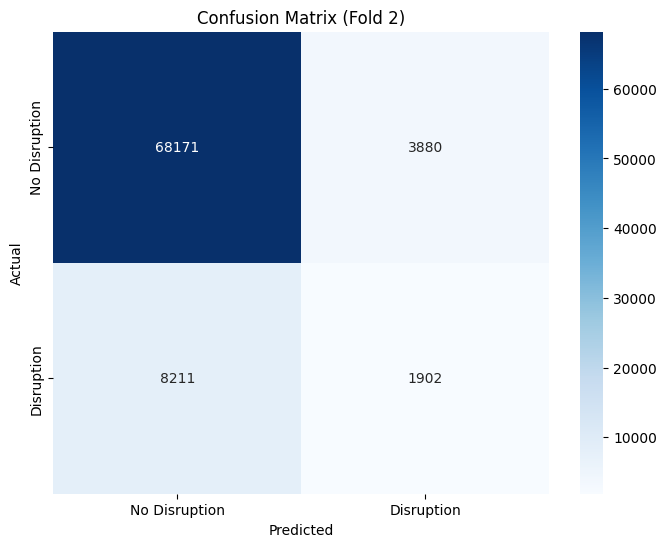


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 125s 20ms/step - AUC: 0.8925 - Precision: 0.8461 - Recall: 0.8461 - accuracy: 0.8461 - loss: 0.4007 - val_AUC: 0.9123 - val_Precision: 0.8162 - val_Recall: 0.8162 - val_accuracy: 0.8162 - val_loss: 0.3740
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 116s 19ms/step - AUC: 0.9228 - Precision: 0.8546 - Recall: 0.8546 - accuracy: 0.8546 - loss: 0.3530 - val_AUC: 0.9377 - val_Precision: 0.8721 - val_Recall: 0.8721 - val_accuracy: 0.8721 - val_loss: 0.3272
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 121s 20ms/step - AUC: 0.9255 - Precision: 0.8587 - Recall: 0.8587 - accuracy: 0.8587 - loss: 0.3466 - val_AUC: 0.9375 - val_Precision: 0.8721 - val_Recall: 0.8721 - val_accuracy: 0.8721 - val_loss: 0.3266
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 122s 20ms/step - AUC: 0.9282 - Precision: 0.8629 - Recall: 0.8629 - accuracy: 0.8629 - loss: 0.3398 - val_AUC: 0.9302 - val_Precision: 0.8580 - val_Recall: 0.8580 - val_accuracy: 0.8580 - val_loss: 0.3387
Epoch 5/50
6163/6163 ━━

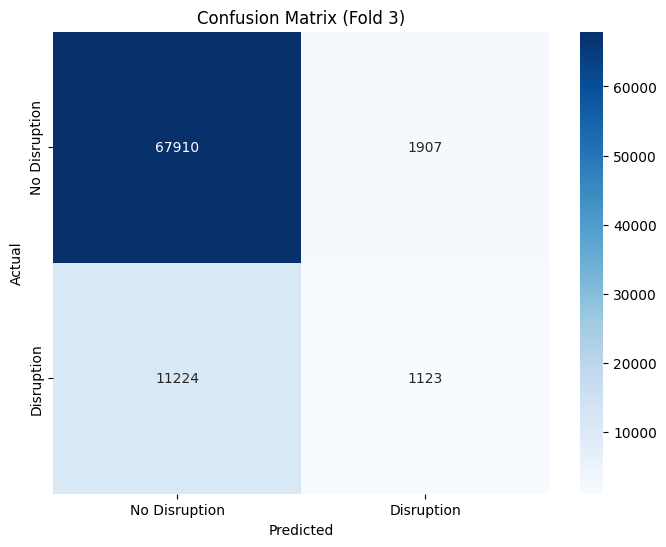


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 170s 20ms/step - AUC: 0.9007 - Precision: 0.8540 - Recall: 0.8540 - accuracy: 0.8540 - loss: 0.3850 - val_AUC: 0.9092 - val_Precision: 0.8400 - val_Recall: 0.8400 - val_accuracy: 0.8400 - val_loss: 0.3830
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 165s 20ms/step - AUC: 0.9265 - Precision: 0.8615 - Recall: 0.8615 - accuracy: 0.8615 - loss: 0.3439 - val_AUC: 0.9095 - val_Precision: 0.8351 - val_Recall: 0.8351 - val_accuracy: 0.8351 - val_loss: 0.3823
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 165s 20ms/step - AUC: 0.9287 - Precision: 0.8652 - Recall: 0.8652 - accuracy: 0.8652 - loss: 0.3384 - val_AUC: 0.9119 - val_Precision: 0.8446 - val_Recall: 0.8446 - val_accuracy: 0.8446 - val_loss: 0.3766
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 167s 20ms/step - AUC: 0.9299 - Precision: 0.8666 - Recall: 0.8666 - accuracy: 0.8666 - loss: 0.3354 - val_AUC: 0.9051 - val_Precision: 0.8310 - val_Recall: 0.8310 - val_accuracy: 0.8310 - val_loss: 0.3908
Epoch 5/50
8217/8217 ━━

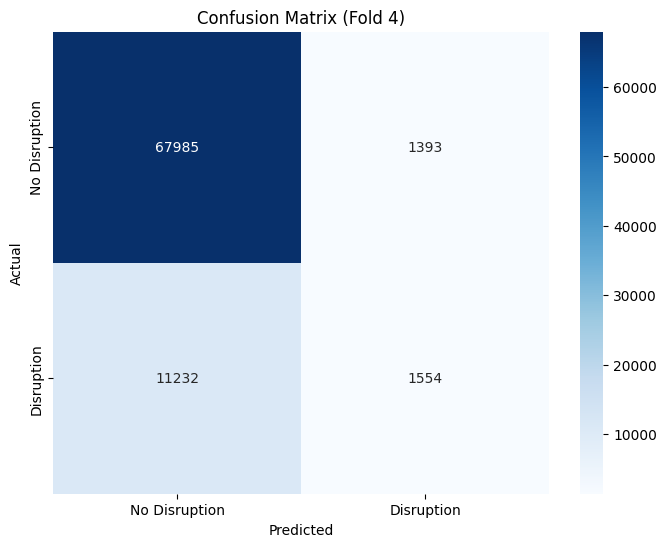


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 222s 21ms/step - AUC: 0.9041 - Precision: 0.8542 - Recall: 0.8542 - accuracy: 0.8542 - loss: 0.3816 - val_AUC: 0.9048 - val_Precision: 0.8403 - val_Recall: 0.8403 - val_accuracy: 0.8403 - val_loss: 0.3909
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 207s 20ms/step - AUC: 0.9230 - Precision: 0.8562 - Recall: 0.8562 - accuracy: 0.8562 - loss: 0.3522 - val_AUC: 0.9110 - val_Precision: 0.8452 - val_Recall: 0.8452 - val_accuracy: 0.8452 - val_loss: 0.3813
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 204s 20ms/step - AUC: 0.9254 - Precision: 0.8609 - Recall: 0.8609 - accuracy: 0.8609 - loss: 0.3460 - val_AUC: 0.9072 - val_Precision: 0.8405 - val_Recall: 0.8405 - val_accuracy: 0.8405 - val_loss: 0.3891
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 208s 20ms/step - AUC: 0.9263 - Precision: 0.8617 - Recall: 0.8617 - accuracy: 0.8617 - loss: 0.3441 - val_AUC: 0.9094 - val_Precision: 0.8418 - val_Recall: 0.8418 - val_accuracy: 0.8418 - val_loss: 0.3827
Epoch 5/50
1027

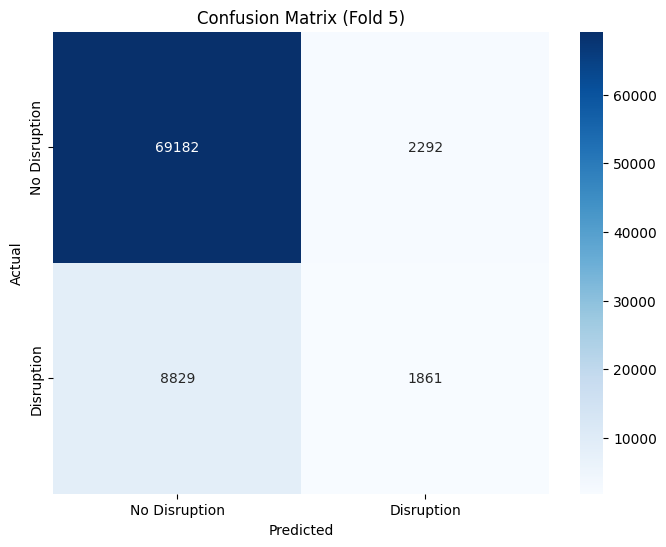


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 258s 21ms/step - AUC: 0.8998 - Precision: 0.8501 - Recall: 0.8501 - accuracy: 0.8501 - loss: 0.3896 - val_AUC: 0.9238 - val_Precision: 0.8586 - val_Recall: 0.8586 - val_accuracy: 0.8586 - val_loss: 0.3579
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 264s 21ms/step - AUC: 0.9191 - Precision: 0.8523 - Recall: 0.8523 - accuracy: 0.8523 - loss: 0.3606 - val_AUC: 0.9271 - val_Precision: 0.8679 - val_Recall: 0.8679 - val_accuracy: 0.8679 - val_loss: 0.3441
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 269s 22ms/step - AUC: 0.9212 - Precision: 0.8562 - Recall: 0.8562 - accuracy: 0.8562 - loss: 0.3557 - val_AUC: 0.9247 - val_Precision: 0.8674 - val_Recall: 0.8674 - val_accuracy: 0.8674 - val_loss: 0.3538
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 268s 22ms/step - AUC: 0.9232 - Precision: 0.8587 - Recall: 0.8587 - accuracy: 0.8587 - loss: 0.3507 - val_AUC: 0.9253 - val_Precision: 0.8677 - val_Recall: 0.8677 - val_accuracy: 0.8677 - val_loss: 0.3467
Epoch 5/50
1232

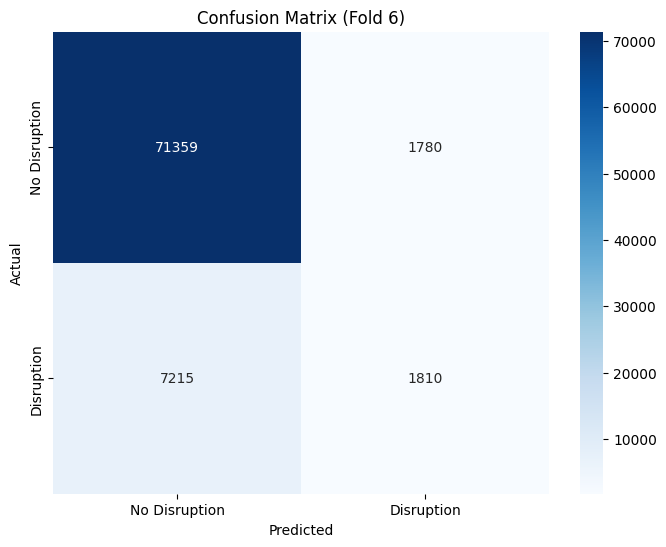


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8509 ± 0.0242
Precision: 0.8509 ± 0.0242
Recall: 0.8509 ± 0.0242
F1: 0.2314 ± 0.0470
Auc: 0.7408 ± 0.0189
Balanced_acc: 0.5631 ± 0.0177

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Test Loss: 0.4196
Test Accuracy: 0.8309
Test Precision: 0.8309
Test Recall: 0.8309
Test F1 Score: 0.5644
Test Balanced Accuracy: 0.7388
Test AUC: 0.8391

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90     66970
           1       0.54      0.59      0.56     15194

    accuracy                           0.83     82164
   macro avg       0.72      0.74      0.73     82164
weighted avg       0.84      0.83      0.83     82164



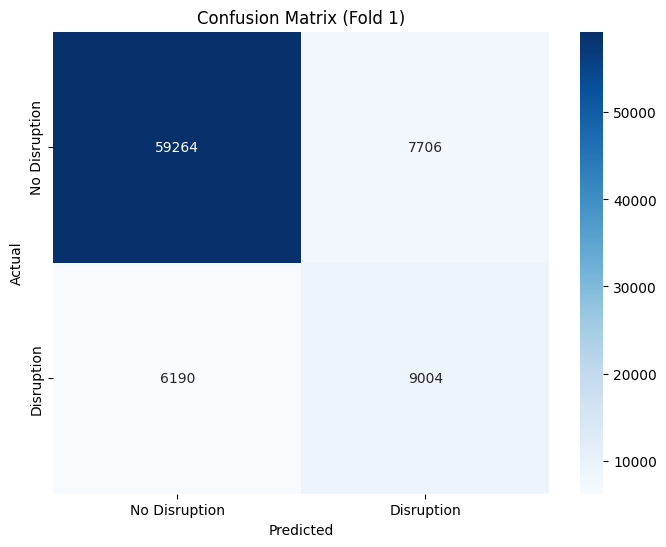


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
Test Loss: 0.4848
Test Accuracy: 0.8135
Test Precision: 0.8135
Test Recall: 0.8135
Test F1 Score: 0.3599
Test Balanced Accuracy: 0.6470
Test AUC: 0.7760

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89     72051
           1       0.31      0.43      0.36     10113

    accuracy                           0.81     82164
   macro avg       0.61      0.65      0.63     82164
weighted avg       0.84      0.81      0.83     82164



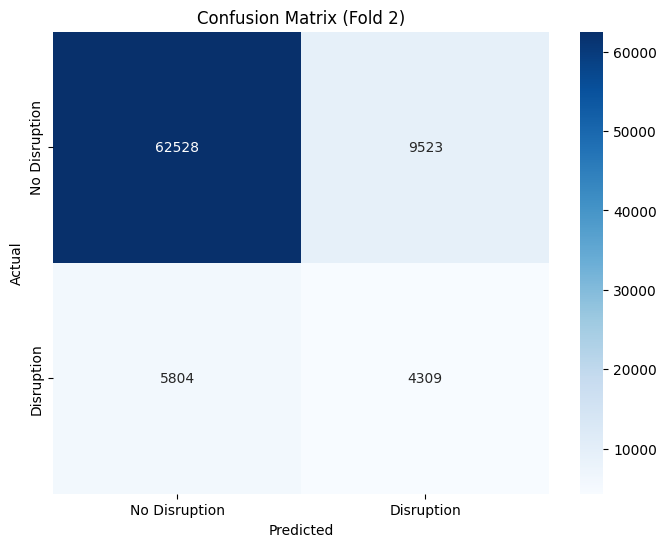


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
Test Loss: 0.4761
Test Accuracy: 0.7981
Test Precision: 0.7981
Test Recall: 0.7981
Test F1 Score: 0.3319
Test Balanced Accuracy: 0.6069
Test AUC: 0.7482

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     69817
           1       0.33      0.33      0.33     12347

    accuracy                           0.80     82164
   macro avg       0.61      0.61      0.61     82164
weighted avg       0.80      0.80      0.80     82164



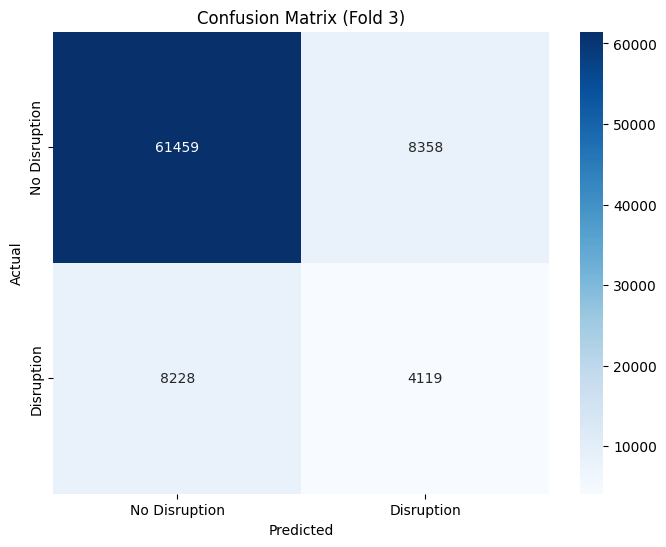


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Test Loss: 0.4272
Test Accuracy: 0.8195
Test Precision: 0.8195
Test Recall: 0.8195
Test F1 Score: 0.3581
Test Balanced Accuracy: 0.6172
Test AUC: 0.7574

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     69378
           1       0.40      0.32      0.36     12786

    accuracy                           0.82     82164
   macro avg       0.64      0.62      0.63     82164
weighted avg       0.81      0.82      0.81     82164



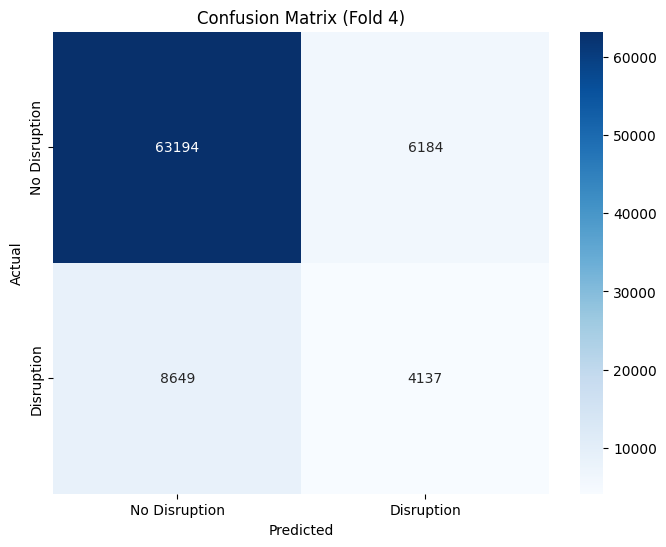


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
Test Loss: 0.3543
Test Accuracy: 0.8651
Test Precision: 0.8651
Test Recall: 0.8651
Test F1 Score: 0.2752
Test Balanced Accuracy: 0.5810
Test AUC: 0.7587

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     71474
           1       0.46      0.20      0.28     10690

    accuracy                           0.87     82164
   macro avg       0.67      0.58      0.60     82164
weighted avg       0.83      0.87      0.84     82164



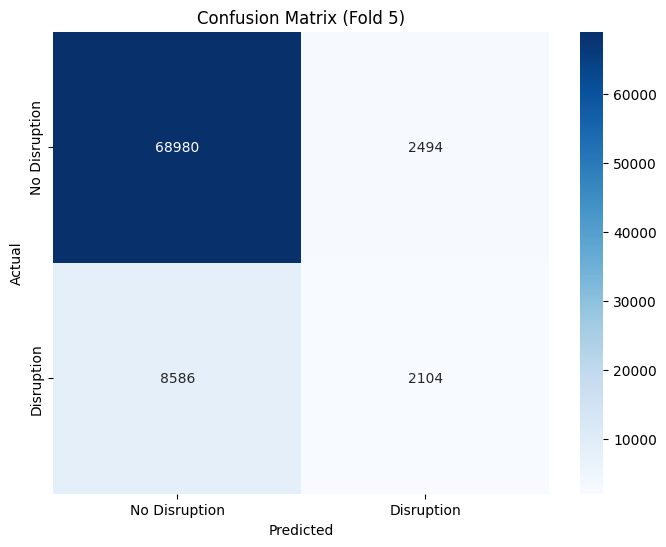


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Test Loss: 0.3212
Test Accuracy: 0.8905
Test Precision: 0.8905
Test Recall: 0.8905
Test F1 Score: 0.2870
Test Balanced Accuracy: 0.5881
Test AUC: 0.7734

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     73139
           1       0.50      0.20      0.29      9025

    accuracy                           0.89     82164
   macro avg       0.71      0.59      0.61     82164
weighted avg       0.86      0.89      0.87     82164



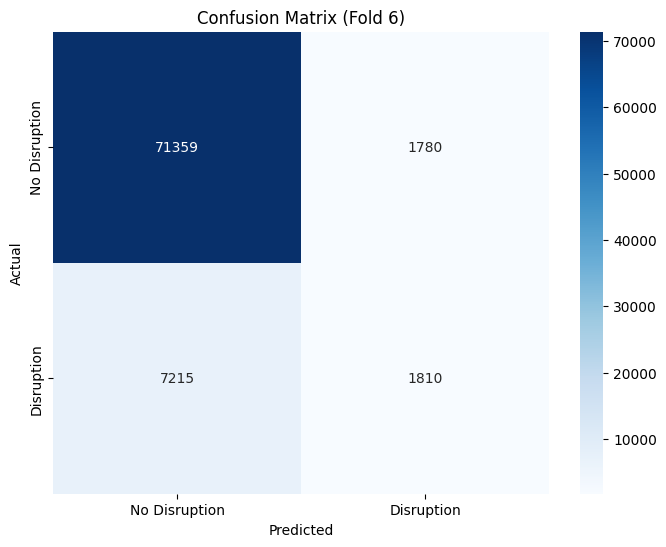


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8363 ± 0.0318
Precision: 0.8363 ± 0.0318
Recall: 0.8363 ± 0.0318
F1: 0.3627 ± 0.0958
Auc: 0.7755 ± 0.0300
Balanced_acc: 0.6298 ± 0.0532


({'accuracy': [0.8308748602867126,
   0.8134584426879883,
   0.7981354594230652,
   0.8194708228111267,
   0.8651477694511414,
   0.8905238509178162],
  'precision': [0.8308748602867126,
   0.8134584426879883,
   0.7981354594230652,
   0.8194708228111267,
   0.8651477694511414,
   0.8905238509178162],
  'recall': [0.8308748602867126,
   0.8134584426879883,
   0.7981354594230652,
   0.8194708228111267,
   0.8651477694511414,
   0.8905238509178162],
  'f1': [0.5644433299899699,
   0.35990812278137396,
   0.3318562681276184,
   0.3580733111178431,
   0.27524856096284667,
   0.2869599682917162],
  'auc': [0.8390664896073399,
   0.7760085993231858,
   0.7481947335369163,
   0.7573890463764101,
   0.7587371262559893,
   0.7734415889844174],
  'balanced_acc': [0.7387679476835054,
   0.6469574842708505,
   0.6069451702775541,
   0.6172110656142151,
   0.5809628249492257,
   0.5881083978561824]},
 {'accuracy': 0.8362685342629751,
  'precision': 0.8362685342629751,
  'recall': 0.8362685342629751

In [31]:
wno_reshaped = X_wno.reshape((X_wno.shape[0], X_wno.shape[1], 1))

final_model_wno, cv_metrics, feature_importance = cross_validate_lstm(
    X=wno_reshaped, 
    y=y, 
    features=wthr_features + oper_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(wno_reshaped, y, final_model_wno, n_splits=6)